**PRAICP-1002 Traffic Sign Detection**

**Domain Analysis**
**Problem Statement**
Traffic sign recognition is a safety-critical computer vision task that form the backbone of:
* Autonomous Vehicle which is a real-time sign detection at highway speeds.
* Advanced Driver Assistance Systems(ADAS) which is helpful for lane keeping, speed adaptation.
* Smart city infrastructure which is automated traffic monitoring.

Misclassification of a stop sign as a speed limit sign can be fatal. This makes accuracy, robustness, and explainability non-negotiable.

**Dataset Overview**
|Property|Value|
|--------|-----|
|Total Classes|43 traffic sign categories|
|Training images| 39,209|
|Test images| 12,630|
|Image Size| Variable(15*15 to 250*250px)|
|format|PPM images with csv annotations|
|Bounding Box| ROI coordinates per image|
|Class type| Speed limits, prohibitions,danger, mandatory,unique signs.|

**Challenges**
* Class imbalance
* Lighting variance
* small resolution
* Intra-class similarity

**Project Architecture**

Import libraries→ Data loading→ Raw images→ EDA→ Preprocessing→ Feature Engineering→ Deep Learning Model(MobileNetV2+VGG16)→ Transfer learning → machine learning : Logistic Regression, Random Forest, Decision Tree, KNeighbors, LightGBM, XGBoost, SVM(using CNN features)→ Model Comparison→ Plotting curves for training, testing, confusion matrix→  Final Dashborad→ Conclusion→ Future scope.

In [ ]:
# Import all the libraries.
import os
import gc
import time
import random
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import cv2
from PIL import Image
from skimage.feature import hog
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              classification_report, roc_auc_score,
                              roc_curve, auc)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
print('Libraries imported Successfully!!')

Libraries imported Successfully!!


**Load the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile
zip_path ="/content/drive/MyDrive/Artificial Intelligence Capstone Project Files/PRAICP-1002-TrafSignDetc.zip"
with zipfile.ZipFile(zip_path,'r')as z:
  z.extractall("/content/gtsrb_local/")
print(sorted(os.listdir("/content/gtsrb_local/Train")))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [ ]:
# Load the train and test file
train_df = pd.read_csv("/content/drive/MyDrive/Artificaial Intelligence Capstone Project Files/PRAICP-1002-TrafSignDetc/Train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Artificaial Intelligence Capstone Project Files/PRAICP-1002-TrafSignDetc/Test.csv")

In [ ]:
# Configure Parameters
from pathlib import Path
DATA_ROOT = Path('/content/gtsrb_local')
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS_DL = 30
NUM_CLASSES = 43
SEED = 42  # Added SEED for reproducibility
CLASS_NAMES = {
    0:'Speed limit (20km/h)',   1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)',   3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)',   5:'Speed limit (80km/h)',
    6:'End speed limit (80)',   7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)',  9:'No passing',
    10:'No passing >3.5t',      11:'Right-of-way junction',
    12:'Priority road',         13:'Yield',
    14:'Stop',                  15:'No vehicles',
    16:'No trucks',             17:'No entry',
    18:'General caution',       19:'Danger curve left',
    20:'Danger curve right',    21:'Double curve',
    22:'Bumpy road',            23:'Slippery road',
    24:'Road narrows right',    25:'Road work',
    26:'Traffic signals',       27:'Pedestrians',
    28:'Children crossing',     29:'Bicycles crossing',
    30:'Beware ice/snow',       31:'Wild animals crossing',
    32:'End speed+passing',     33:'Turn right ahead',
    34:'Turn left ahead',       35:'Ahead only',
    36:'Go straight or right',  37:'Go straight or left',
    38:'Keep right',            39:'Keep left',
    40:'Roundabout mandatory',  41:'End no passing',
    42:'End no passing >3.5t'
}
SIGN_GROUPS = {
    'Speed Limits':    list(range(0, 9)),
    'Prohibitory':     [9, 10, 15, 16, 17, 41, 42],
    'Danger':          [11, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
    'Mandatory':       [33, 34, 35, 36, 37, 38, 39, 40],
    'Unique':          [12, 13, 14, 32],
}
tf.random.set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
print(f"Configuration loaded - {NUM_CLASSES} classes, IMG_SIZE = {IMG_SIZE}")

Configuration loaded - 43 classes, IMG_SIZE = 64


**Label Mapping and Preprocessing**

In [ ]:
train_df['ClassName'] = train_df['ClassId'].map(CLASS_NAMES)
test_df['ClassName'] = test_df['ClassId'].map(CLASS_NAMES)
def get_group(class_id):
  for grp,ids in SIGN_GROUPS.items():
    if class_id in ids:
      return grp
  return 'Other'
train_df['SignGroup'] = train_df['ClassId'].apply(get_group)
test_df['SignGroup'] = test_df['ClassId'].apply(get_group)
# Compute ROI area and aspect ratio
train_df['ROI_Width'] = train_df['Roi.X2'] - train_df['Roi.X1']
train_df['ROI_Height'] = train_df['Roi.Y2'] - train_df['Roi.Y1']
train_df['ROI_Area'] = train_df['ROI_Width'] * train_df['ROI_Height']
train_df['AspectRatio'] = train_df['ROI_Width'] / (train_df['ROI_Height'] + 1e-6)
print(f'Train CSV : {train_df.shape[0]:,} rows x {train_df.shape[1]}columns')
print(f'Test CSV : {test_df.shape[0]:,} rows x {test_df.shape[1]}columns')
print()
print('Train columns :',list(train_df.columns))
train_df.head(5)

Train CSV : 39,209 rows x 14columns
Test CSV : 12,630 rows x 10columns

Train columns : ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path', 'ClassName', 'SignGroup', 'ROI_Width', 'ROI_Height', 'ROI_Area', 'AspectRatio']


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,ClassName,SignGroup,ROI_Width,ROI_Height,ROI_Area,AspectRatio
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png,Danger curve right,Danger,17,15,255,1.133333
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png,Danger curve right,Danger,18,16,288,1.125000
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png,Danger curve right,Danger,18,16,288,1.125000
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png,Danger curve right,Danger,18,16,288,1.125000
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png,Danger curve right,Danger,18,16,288,1.125000


In [ ]:
# Check for missing values
missing_train = train_df.isnull().sum()
missing_test = test_df.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0  else 'No Missing Values in train')
print(missing_test[missing_test > 0 ] if missing_test.sum() >0 else 'No Missing Values in Test')

No Missing Values in train
No Missing Values in Test


In [ ]:
# Check for duplicates
dup_train = train_df.duplicated().sum()
dup_test = test_df.duplicated().sum()
print(f'Train Duplicates : {dup_train}')
print(f'Test Duplicates : {dup_test}')

Train Duplicates : 0
Test Duplicates : 0


**Data Validation and integrity Checks**

In [ ]:
# Class Coverage
train_classes = set(train_df['ClassId'].unique())
test_classes = set(test_df['ClassId'].unique())
print(f'Classes in train: {len(train_classes)} | classes in test:{len(test_classes)}')
missing_in_test = train_classes - test_classes
print(f'Classes in train but NOT in test :{missing_in_test if missing_in_test else 'None Complete'}')
# File Existence spot check
sample_path = train_df['Path'].sample(min(10,len(train_df)),random_state = 42)
missing_files = [p for p in sample_path if not (DATA_ROOT / p).exists()]
print(f"Missing Files: {len(missing_files)}")
if not missing_files:
  print('All Spot-Checked Files Exist')

Classes in train: 43 | classes in test:43
Classes in train but NOT in test :None Complete
Missing Files: 0
All Spot-Checked Files Exist


**Statistical Summary**

In [ ]:
# Check the statistical summary
numerical_cols = ['Width','Height','ROI_Width','ROI_Height','ROI_Area','AspectRatio']
desc = train_df[numerical_cols].describe().T
desc['Skewness'] = train_df[numerical_cols].skew()
desc['Kurtosis'] = train_df[numerical_cols].kurtosis()
print(desc.round(2).to_string())

               count     mean      std     min     25%     50%      75%       max  Skewness  Kurtosis
Width        39209.0    50.84    24.31   25.00   35.00    43.0    58.00    243.00      2.11      5.90
Height       39209.0    50.33    23.12   25.00   35.00    43.0    58.00    225.00      2.02      5.23
ROI_Width    39209.0    39.20    21.82   15.00   24.00    33.0    47.00    203.00      1.87      4.60
ROI_Height   39209.0    38.77    20.83   15.00   24.00    32.0    47.00    185.00      1.77      4.00
ROI_Area     39209.0  1966.08  2584.39  225.00  576.00  1056.0  2209.00  37555.00      3.82     21.84
AspectRatio  39209.0     1.01     0.08    0.33    0.97     1.0     1.05      1.44     -0.58      5.12


In [ ]:
# Class Distribution Summary
class_counts = train_df['ClassId'].value_counts().sort_index()
print('Class Distribution Summary')
print(f"Total Samples : {len(train_df):,}")
print(f"classes: {NUM_CLASSES}")
print(f"Mean Per Class : {class_counts.mean():.0f}")
print(f"Median Per Class: {class_counts.median():.0f}")
print(f"Standard Deviation : {class_counts.std():.0f}")
print(f"Max Class (id {class_counts.idxmax()}):{class_counts.max()} samples {CLASS_NAMES[class_counts.idxmax()]}")
print(f"Min Class (id {class_counts.idxmin()}):{class_counts.min()} samples {CLASS_NAMES[class_counts.idxmin()]}")
print(f"Imbalance Ratio : {class_counts.max()/class_counts.min():.1f}x")
print(f"Classes < 500 samples: {(class_counts < 500).sum()}")
print(f"Classes >1500 samples: {(class_counts >1500).sum()}")
# Sign Group Breakdown
print('Sign Group Breakdown')
grp_counts = train_df['SignGroup'].value_counts()
for grp, cnt in grp_counts.items():
  pct = cnt/ len(train_df)*100
  bar = '█'*int(pct/2)
  print(f"{grp:<20} {cnt:5d} ({pct:4.1f}%) {bar}")

Class Distribution Summary
Total Samples : 39,209
classes: 43
Mean Per Class : 912
Median Per Class: 600
Standard Deviation : 696
Max Class (id 2):2250 samples Speed limit (50km/h)
Min Class (id 0):210 samples Speed limit (20km/h)
Imbalance Ratio : 10.7x
Classes < 500 samples: 19
Classes >1500 samples: 8
Sign Group Breakdown
Speed Limits         13200 (33.7%) ████████████████
Danger                8970 (22.9%) ███████████
Prohibitory           6120 (15.6%) ███████
Mandatory             5639 (14.4%) ███████
Unique                5280 (13.5%) ██████


**Normality Checking and Correlation Analysis of Image Features**

In [ ]:
# Noramlity test on Image Dimensions
print('Shapiro-Wilk Normality Test')
for col in ['Width','Height','ROI_Area']:
  sample = train_df[col].sample(200,random_state = 42)
  stat, p = stats.shapiro(sample)
  normal = 'Normal' if p > 0.05 else 'Not Normal'
  print(f" {col:<12} : W = {stat:.4f}, p = {p:.4f} → {normal}")
# Correlation between image dimensions
print('Pearson Correlation- width Vs Height:', round(train_df['Width'].corr(train_df['Height']),4))
print('Pearson Correlation - ROI_Area Vs ClassId:',round(train_df['ROI_Area'].corr(train_df['ClassId']),4))

Shapiro-Wilk Normality Test
 Width        : W = 0.7486,p = 0.0000 Normal
 Height       : W = 0.7572,p = 0.0000 Normal
 ROI_Area     : W = 0.5505,p = 0.0000 Normal
Pearson Correlation- width Vs Height: 0.9812
Pearson Correlation - ROI_Area Vs ClassId: 0.0481


**Exploratory Data Analysis(EDA)**

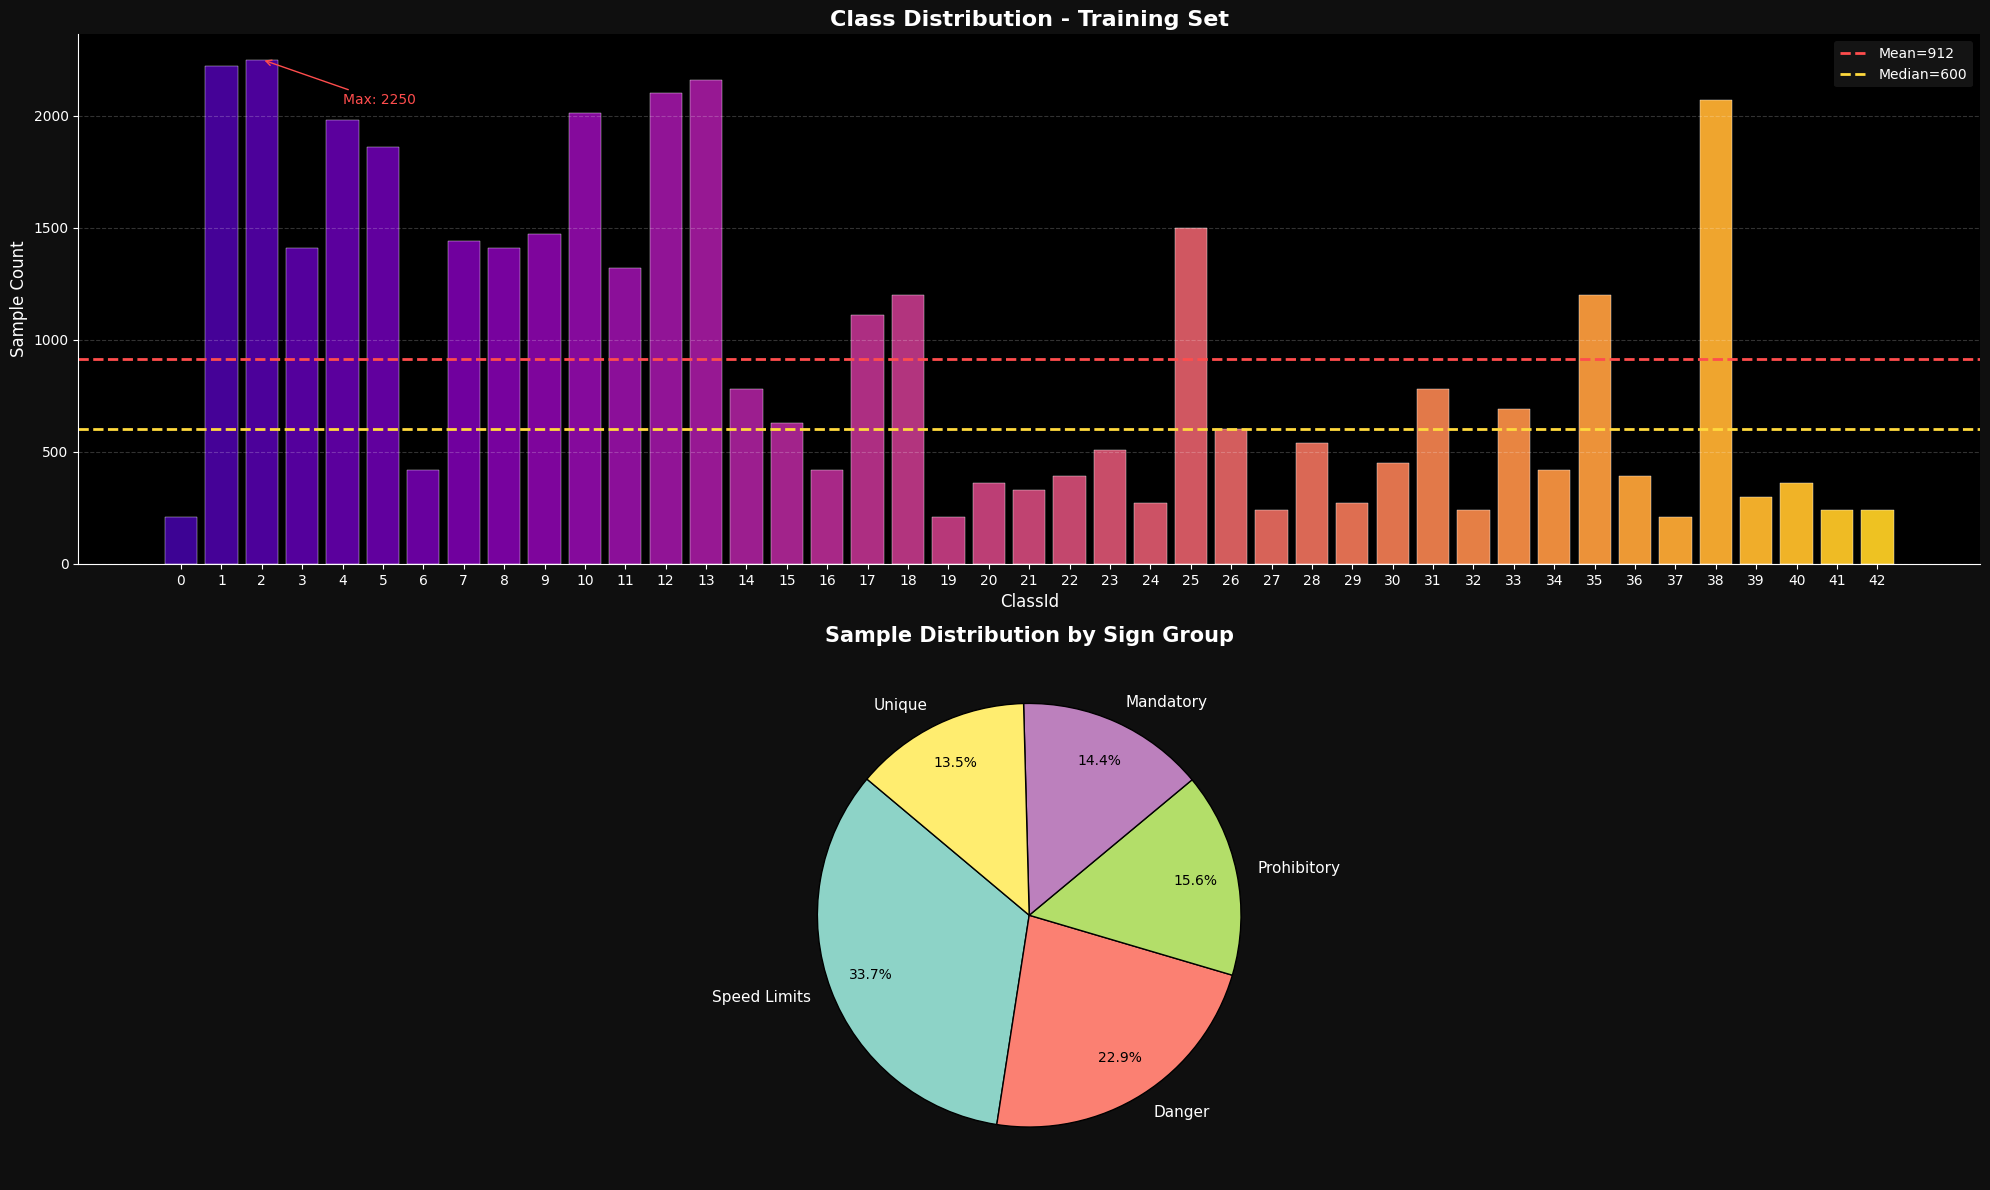

In [ ]:
plt.style.use('dark_background')
# Class Distribution Plot
class_counts = train_df['ClassId'].value_counts().sort_index()
colors = plt.cm.plasma(np.linspace(0.1, 0.9, NUM_CLASSES))
fig, axes = plt.subplots(2, 1, figsize=(20, 12), facecolor='#0f0f0f')
# Bar Chart
bars = axes[0].bar(class_counts.index,class_counts.values,color=colors,edgecolor='white',linewidth=0.3,alpha=0.95)
# Mean & Median lines
axes[0].axhline(class_counts.mean(), color='#ff4d4d', lw=2, linestyle='--',
                label=f'Mean={class_counts.mean():.0f}')
axes[0].axhline(class_counts.median(), color='#ffd93d', lw=2, linestyle='--',
                label=f'Median={class_counts.median():.0f}')
# Titles & labels
axes[0].set_title('Class Distribution - Training Set', fontsize=16, fontweight='bold', color='white')
axes[0].set_xlabel('ClassId', fontsize=12, color='white')
axes[0].set_ylabel('Sample Count', fontsize=12, color='white')

axes[0].legend(facecolor='#1a1a1a', edgecolor='none')
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].grid(axis='y', linestyle='--', alpha=0.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].annotate(
    f'Max: {class_counts.max()}',
    xy=(class_counts.idxmax(), class_counts.max()),
    xytext=(class_counts.idxmax()+2, class_counts.max()-200),
    color='#ff4d4d',
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='#ff4d4d')
)
# Pie Chart
grp_counts = train_df['SignGroup'].value_counts()

wedges, texts, autotexts = axes[1].pie(
    grp_counts.values,
    labels=grp_counts.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(grp_counts))),
    startangle=140,
    pctdistance=0.8,
    wedgeprops=dict(edgecolor='black')  # cleaner separation
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(11)
for at in autotexts:
    at.set_fontsize(10)
    at.set_color('black')  # better contrast on light slices

axes[1].set_title('Sample Distribution by Sign Group',
                  fontsize=15, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('EDA_Class_Distribution.png',
            dpi=150,
            bbox_inches='tight',
            facecolor='#0f0f0f')

plt.show()

**Insights:**
* The dataset is highly imbalanced, with some classes having significantly more samples than others.
* The mean sample count is higher than the median, indicating a right-skewed distribution.
* Certain Classes dominate the dataset, which may bias the model during training.
* Some classes have very low samples, which can lead to poor generalization for those categories.
* Techniques like data augmentation, class weighting, or resampling may be required to handle imbalance.

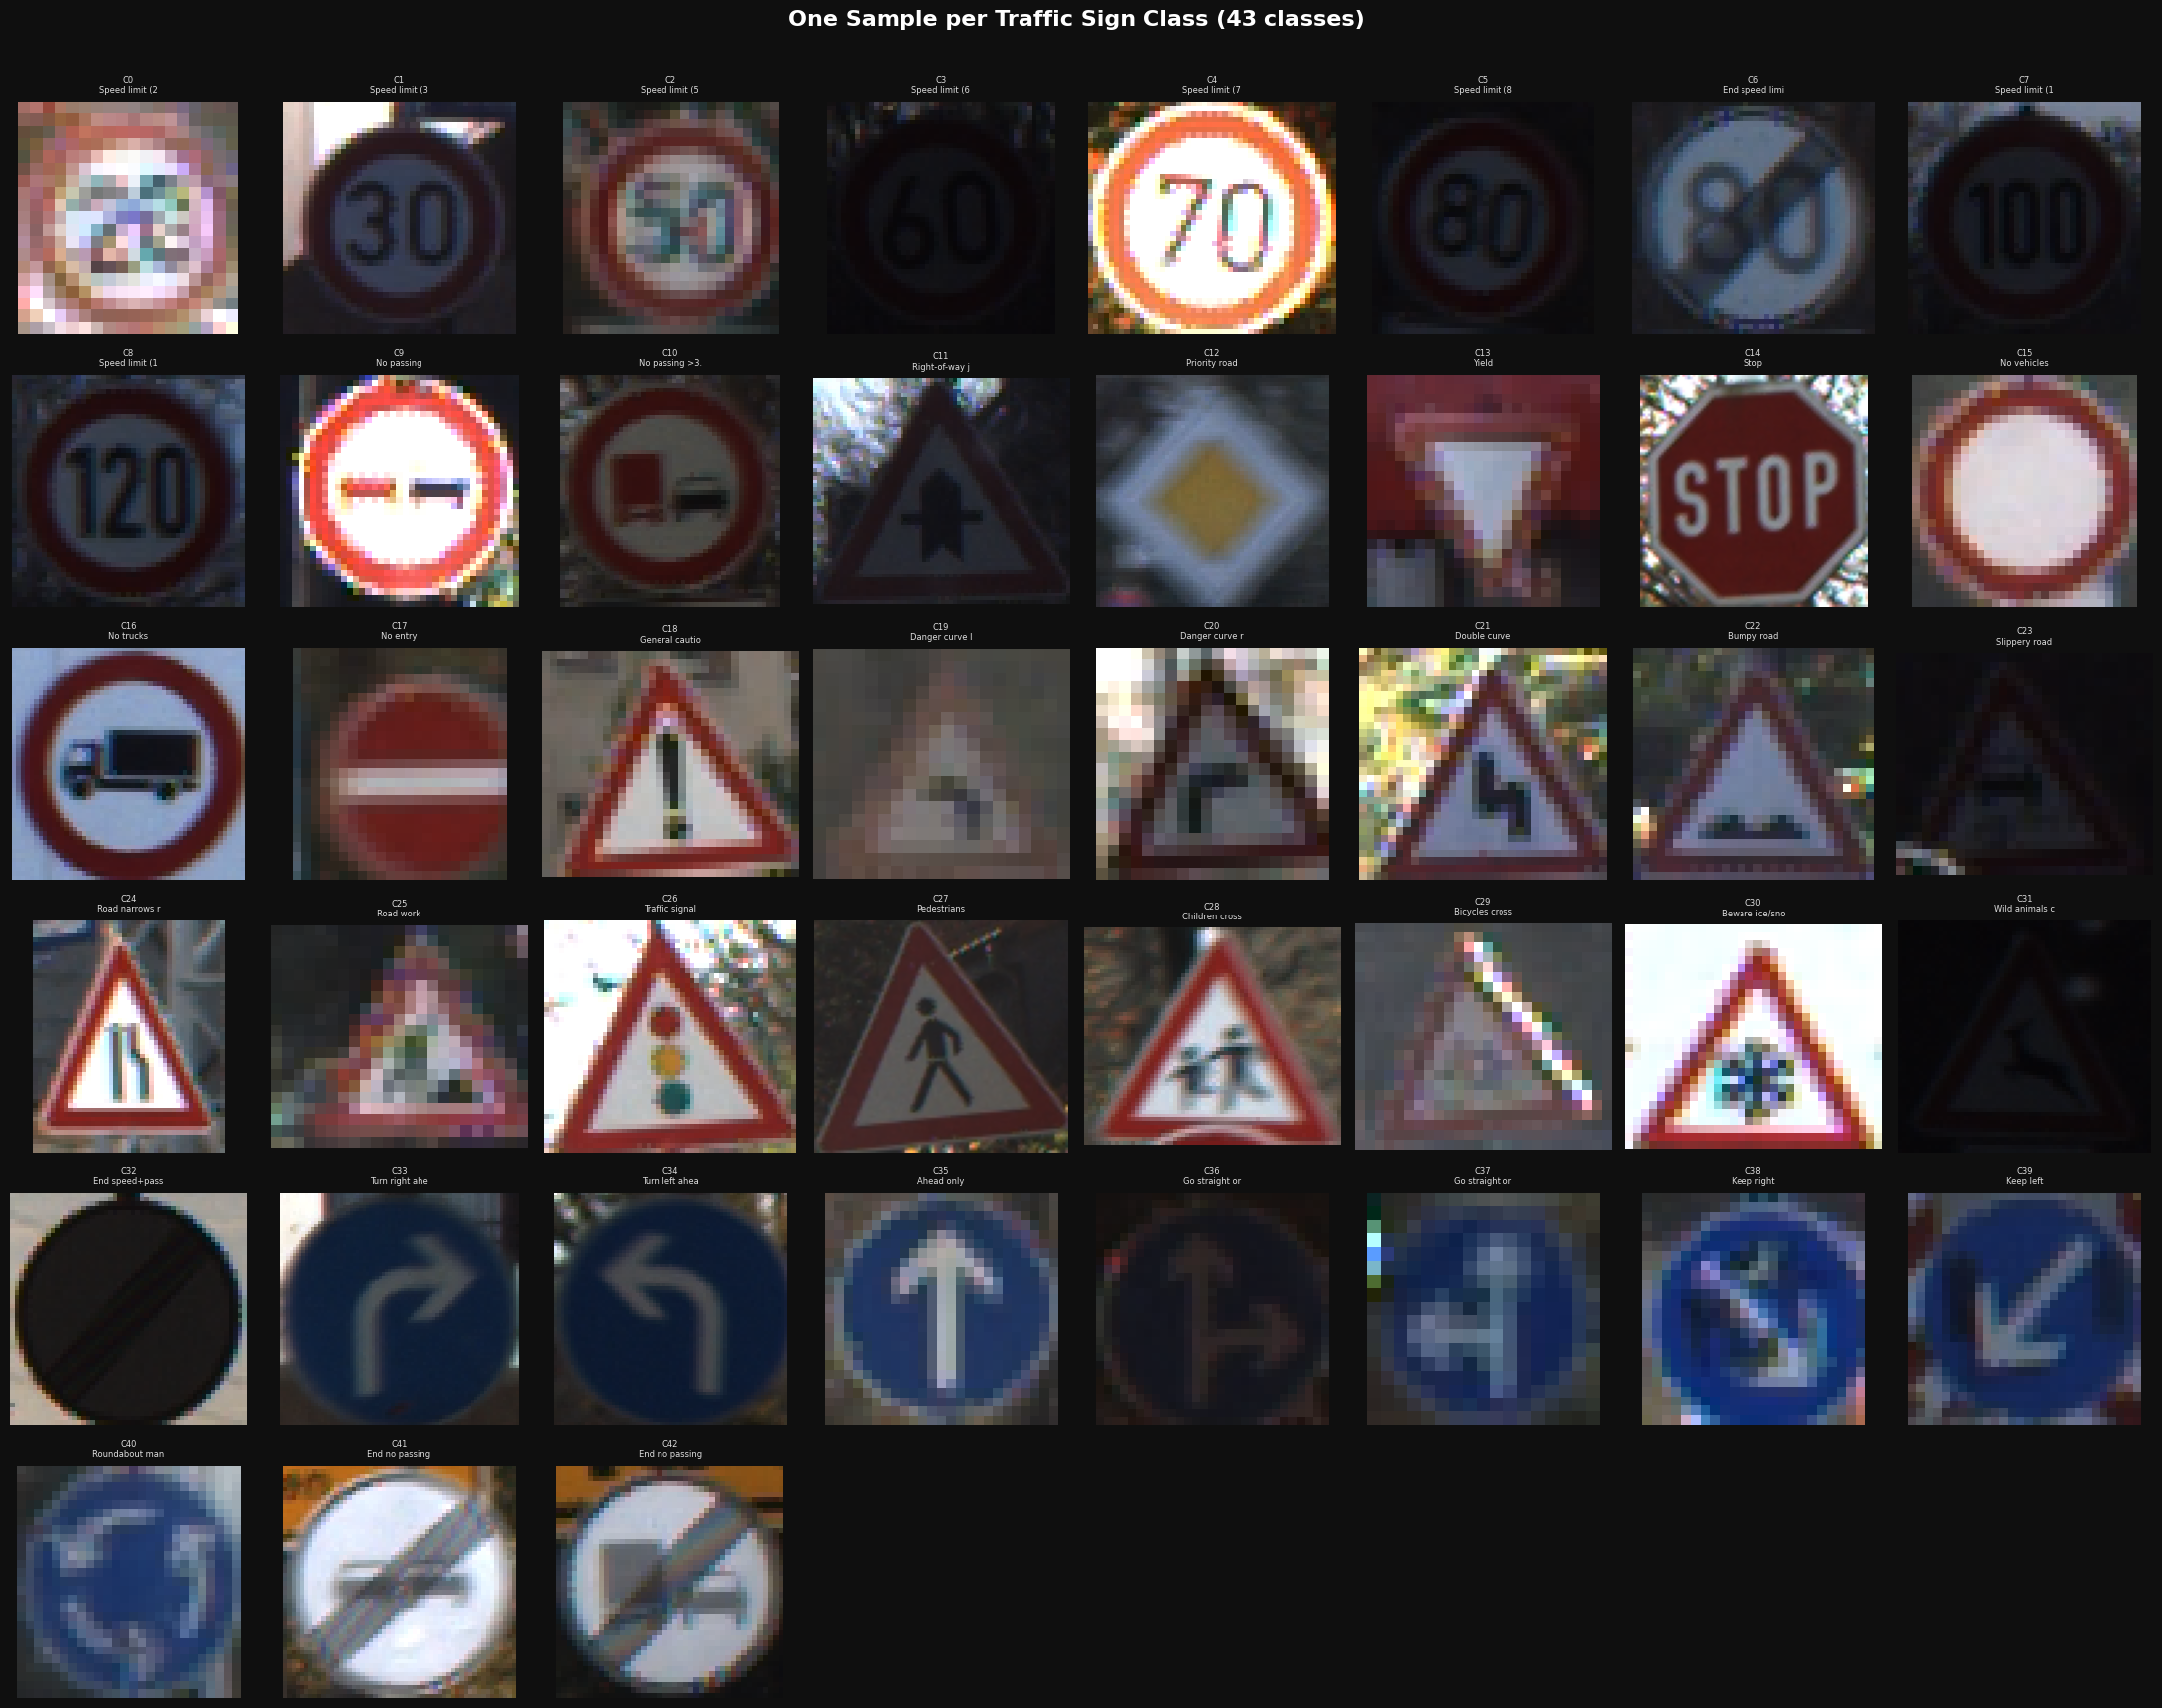

In [ ]:
# Sample Images Plot for Per Class
fig, axes = plt.subplots(6, 8, figsize=(22, 17))
axes = axes.flatten()
fig.patch.set_facecolor('#0f0f0f')
for cls_id in range(NUM_CLASSES):
    row = train_df[train_df['ClassId'] == cls_id].sample(1, random_state=42).iloc[0]
    try:
        img = Image.open(DATA_ROOT / row['Path'])
        img = img.crop((row['Roi.X1'], row['Roi.Y1'], row['Roi.X2'], row['Roi.Y2']))
        axes[cls_id].imshow(img)
    except (FileNotFoundError, OSError, Exception) as e:
        axes[cls_id].text(0.5, 0.5, 'N/A', ha='center', color='red')
    axes[cls_id].set_title(f"C{cls_id}\n{CLASS_NAMES[cls_id][:14]}", fontsize=6, color='#ddd')
    axes[cls_id].axis('off')
for i in range(NUM_CLASSES, len(axes)):
    axes[i].axis('off')

plt.suptitle('One Sample per Traffic Sign Class (43 classes)', fontsize=16, fontweight='bold', color='#fff', y=1.01)
plt.tight_layout()
plt.savefig('EDA_Sample_Grid.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

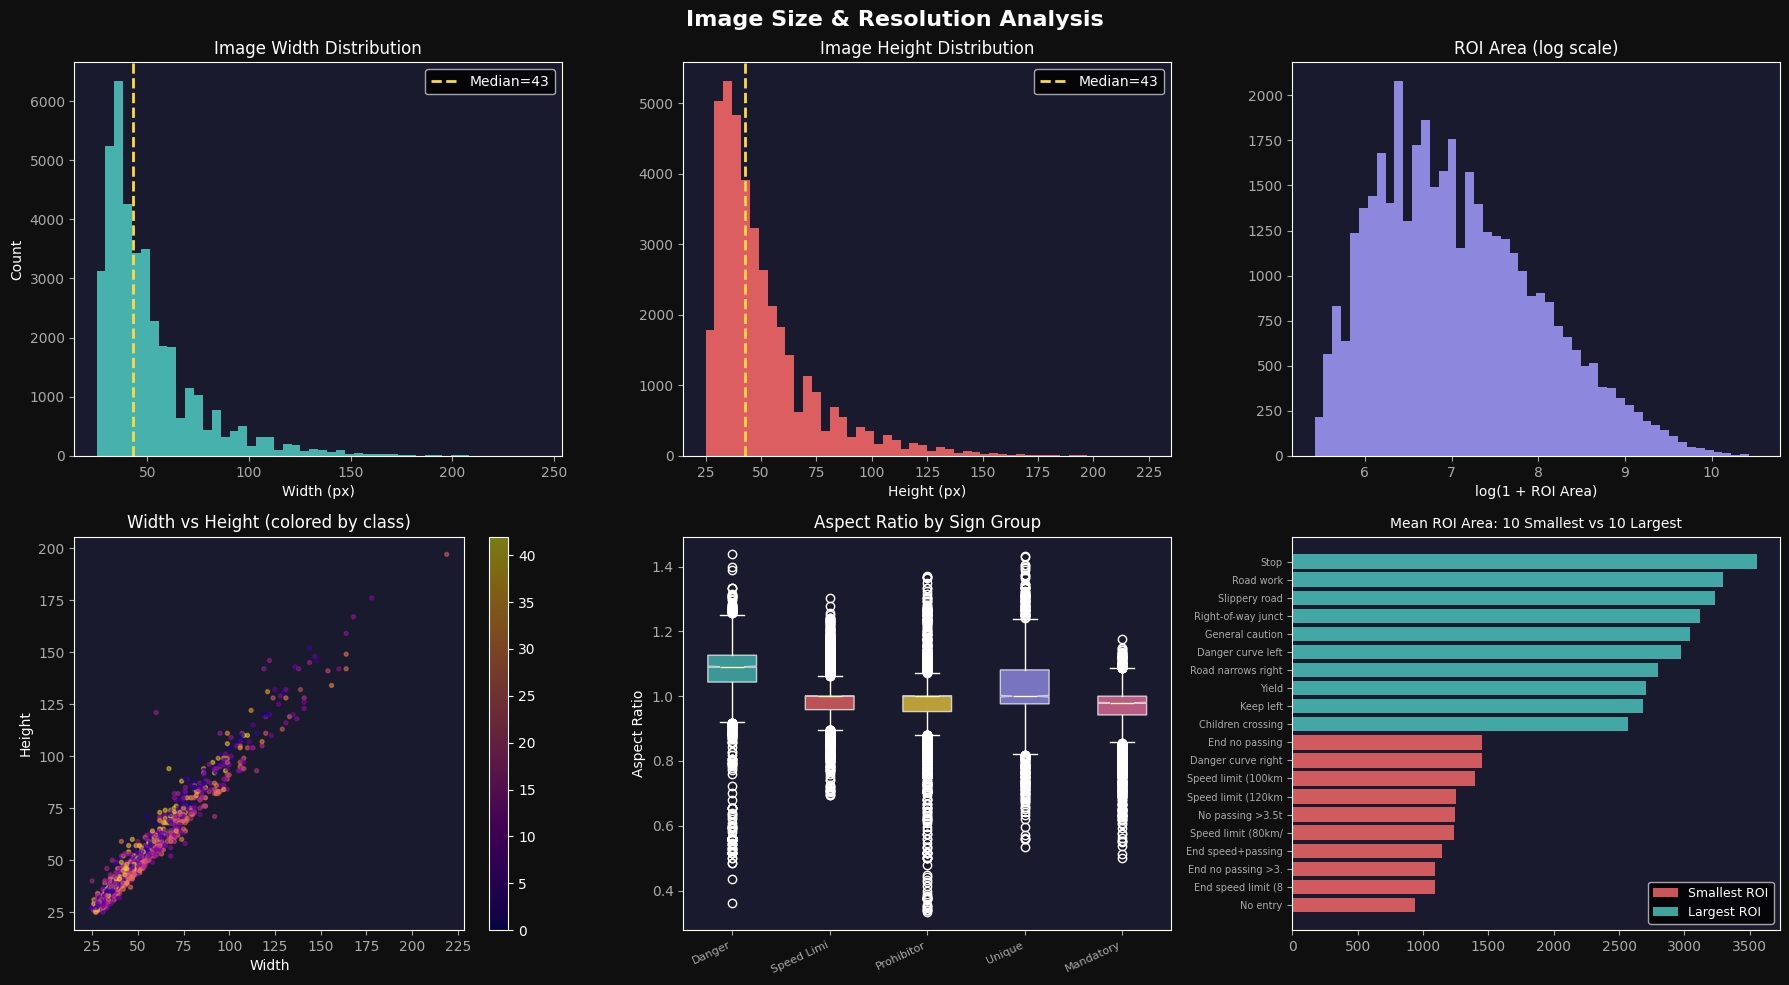

In [ ]:
# Image Size & Resolution Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f0f0f')

# Width distribution
axes[0,0].hist(train_df['Width'], bins=50, color='#4ecdc4', edgecolor='none', alpha=0.85)
axes[0,0].set_title('Image Width Distribution', color='#fff', fontsize=12)
axes[0,0].set_xlabel('Width (px)'); axes[0,0].set_ylabel('Count')
axes[0,0].axvline(train_df['Width'].median(), color='#ffd93d', lw=2, linestyle='--', label=f"Median={train_df['Width'].median():.0f}")
axes[0,0].legend()

# Height distribution
axes[0,1].hist(train_df['Height'], bins=50, color='#ff6b6b', edgecolor='none', alpha=0.85)
axes[0,1].set_title('Image Height Distribution', color='#fff', fontsize=12)
axes[0,1].set_xlabel('Height (px)')
axes[0,1].axvline(train_df['Height'].median(), color='#ffd93d', lw=2, linestyle='--', label=f"Median={train_df['Height'].median():.0f}")
axes[0,1].legend()

# ROI Area distribution
axes[0,2].hist(np.log1p(train_df['ROI_Area']), bins=50, color='#a29bfe', edgecolor='none', alpha=0.85)
axes[0,2].set_title('ROI Area (log scale)', color='#fff', fontsize=12)
axes[0,2].set_xlabel('log(1 + ROI Area)')

# Width vs Height scatter
scatter = axes[1,0].scatter(train_df['Width'].sample(2000, random_state=SEED),
                             train_df['Height'].sample(2000, random_state=SEED),
                             c=train_df['ClassId'].sample(2000, random_state=SEED),
                             cmap='plasma', alpha=0.5, s=8)
axes[1,0].set_title('Width vs Height (colored by class)', color='#fff', fontsize=12)
axes[1,0].set_xlabel('Width'); axes[1,0].set_ylabel('Height')
plt.colorbar(scatter, ax=axes[1,0])

# Aspect ratio box per sign group
groups = train_df['SignGroup'].unique()
group_data = [train_df[train_df['SignGroup'] == g]['AspectRatio'].values for g in groups]
bp = axes[1,1].boxplot(group_data, labels=[g[:10] for g in groups],
                        patch_artist=True, notch=True)
colors_bp = ['#4ecdc4','#ff6b6b','#ffd93d','#a29bfe','#fd79a8']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1,1].set_title('Aspect Ratio by Sign Group', color='#fff', fontsize=12)
axes[1,1].set_xticklabels([g[:10] for g in groups], rotation=25, ha='right', fontsize=8)
axes[1,1].set_ylabel('Aspect Ratio')

# ROI area per class (top 10 / bottom 10)
class_mean_area = train_df.groupby('ClassId')['ROI_Area'].mean().sort_values()
axes[1,2].barh(range(10), class_mean_area.values[:10], color='#ff6b6b', alpha=0.8, label='Smallest ROI')
axes[1,2].barh(range(10,20), class_mean_area.values[-10:], color='#4ecdc4', alpha=0.8, label='Largest ROI')
axes[1,2].set_yticks(list(range(10)) + list(range(10,20)))
axes[1,2].set_yticklabels(
    [CLASS_NAMES[i][:18] for i in class_mean_area.index[:10]] +
    [CLASS_NAMES[i][:18] for i in class_mean_area.index[-10:]],
    fontsize=7)
axes[1,2].set_title('Mean ROI Area: 10 Smallest vs 10 Largest', color='#fff', fontsize=10)
axes[1,2].legend(fontsize=9)

for ax in axes.flatten():
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaa')

plt.suptitle('Image Size & Resolution Analysis', fontsize=16, fontweight='bold', color='#fff')
plt.tight_layout()
plt.savefig('eda_size_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Insights:**
1. Image Width & Height Distribution
Both width and height distributions are right-skewed, meaning most images are small while a few are significantly larger.
The median (43 px) shows that a large portion of traffic sign images are low resolution.
* Presence of large images creates high variability, which can affect model consistency.
2. ROI Area Distribution (Log Scale)
After applying log transformation, the ROI area appears more normally distributed, indicating extreme variation in raw values.
* Many traffic signs occupy a small region within the image, making detection challenging.
* The model must learn to handle scale variation effectively.3. Width vs Height Relationship
There is a strong positive linear correlation between width and height.
* Most images follow a consistent shape pattern, suggesting minimal distortion.
* This supports uniform resizing (e.g., 224×224) without losing important features.
4. Aspect Ratio Across Sign Groups
Most sign groups have an aspect ratio close to 1, indicating nearly square shapes.
* Some variation exists, but overall consistency helps CNN models learn spatial features efficiently.
Limited variation reduces complexity in preprocessing.
5. ROI Area Comparison Across Classes
Some classes (e.g., Stop, Road Work) have large ROI areas, meaning signs are clearly visible.
* Other classes (e.g., No Entry, Speed Limit variants) have smaller ROI areas, making them harder to detect.
* This imbalance can lead to:Better performance on large signs
Poor detection accuracy for small signs.

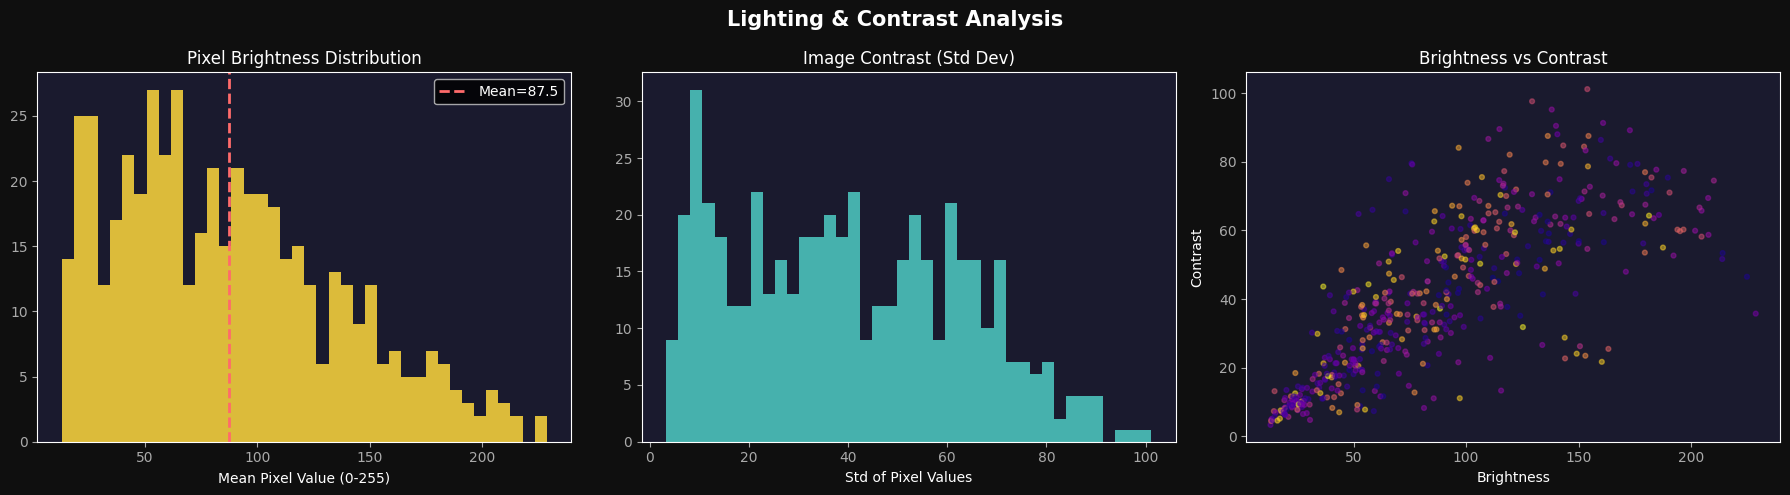

In [ ]:
# Brightness & Contrast Analysis
def get_brightness_contrast(path, roi, root=DATA_ROOT):
    img = cv2.imread(str(root / path))
    if img is None: return None, None
    x1, y1, x2, y2 = roi
    img = img[y1:y2, x1:x2]
    if img.size == 0: return None, None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.mean(), gray.std()
sample_df = train_df.sample(500, random_state=SEED).reset_index(drop=True)
bright, contrast = [], []
for _, row in sample_df.iterrows():
    b, c = get_brightness_contrast(
        row['Path'],
        (int(row['Roi.X1']), int(row['Roi.Y1']), int(row['Roi.X2']), int(row['Roi.Y2']))
    )
    bright.append(b)
    contrast.append(c)

sample_df['Brightness'] = bright
sample_df['Contrast']   = contrast
sample_df = sample_df.dropna(subset=['Brightness'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f0f')
axes[0].hist(sample_df['Brightness'], bins=40, color='#ffd93d', edgecolor='none', alpha=0.85)
axes[0].set_title('Pixel Brightness Distribution', color='#fff', fontsize=12)
axes[0].set_xlabel('Mean Pixel Value (0-255)')
axes[0].axvline(sample_df['Brightness'].mean(), color='#ff6b6b', lw=2, linestyle='--',
                label=f"Mean={sample_df['Brightness'].mean():.1f}")
axes[0].legend()
axes[1].hist(sample_df['Contrast'], bins=40, color='#4ecdc4', edgecolor='none', alpha=0.85)
axes[1].set_title('Image Contrast (Std Dev)', color='#fff', fontsize=12)
axes[1].set_xlabel('Std of Pixel Values')
axes[2].scatter(sample_df['Brightness'], sample_df['Contrast'],
                c=sample_df['ClassId'], cmap='plasma', alpha=0.5, s=12)
axes[2].set_title('Brightness vs Contrast', color='#fff', fontsize=12)
axes[2].set_xlabel('Brightness'); axes[2].set_ylabel('Contrast')
for ax in axes:
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='#aaa')
plt.suptitle('Lighting & Contrast Analysis', fontsize=15, fontweight='bold', color='#fff')
plt.tight_layout()
plt.savefig('EDA_Brightness.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Insights:**
1. Pixel Brightness Distribution
The brightness values are moderately spread, with a mean around 87.5, indicating overall moderate illumination.
* Most images fall in the low to mid brightness range, suggesting many scenes are slightly dark or not brightly lit.
* Very few images are extremely bright, indicating limited overexposure issues.
2. Image Contrast Distribution
Contrast values show a wide spread, indicating variability in image quality.
* Some images have low contrast (dull or washed-out), while others show high contrast (sharp edges and clear features).
* This variation can impact how well the model detects edges and patterns.
3. Brightness vs Contrast Relationship
There is a positive correlation between brightness and contrast.
* As brightness increases, contrast generally improves, making features more distinguishable.
* However, the spread shows inconsistency, meaning not all bright images have high contrast.

Computing average HOG descriptor per class for similarity heatmap...


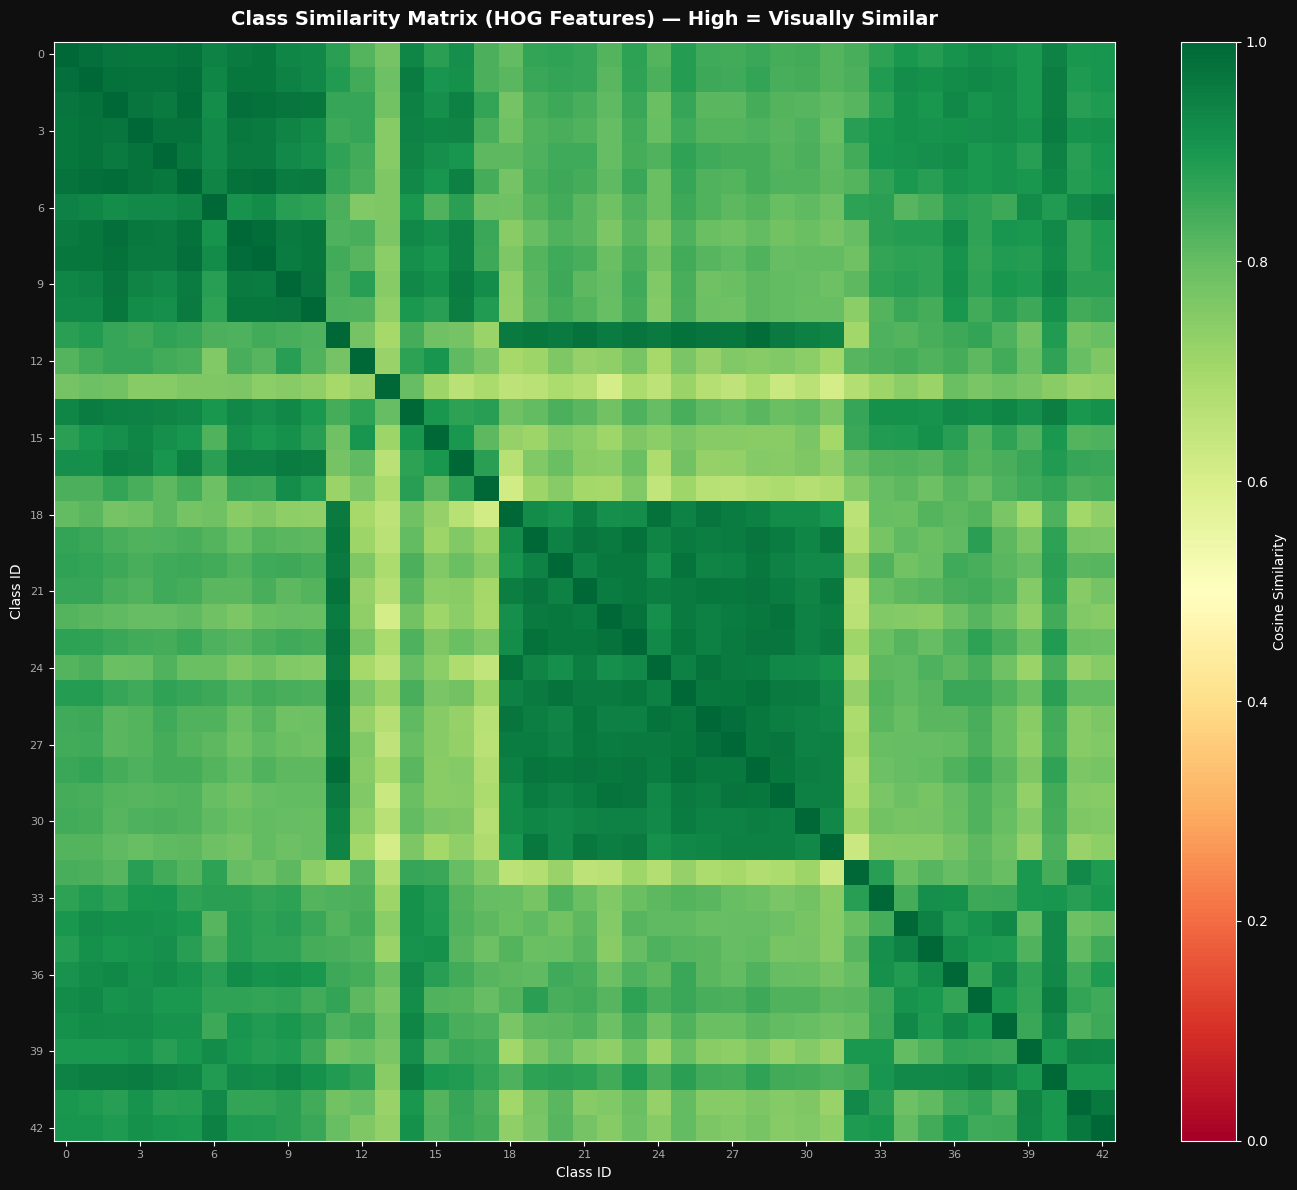

In [ ]:
# Class Similarity Heatmap (HOG cosine distance)
from sklearn.metrics.pairwise import cosine_similarity
print("Computing average HOG descriptor per class for similarity heatmap...")
from skimage.feature import hog as sk_hog
dummy = np.zeros((32, 32), dtype=np.uint8)
HOG_SIZE = len(sk_hog(dummy,
                      orientations=8,
                      pixels_per_cell=(8,8),
                      cells_per_block=(2,2),
                      feature_vector=True))
def avg_hog(class_id, n=20):
    rows = train_df[train_df['ClassId'] == class_id].sample(
        min(n, sum(train_df['ClassId'] == class_id)),
        random_state=SEED
    )

    hogs = []

    for _, row in rows.iterrows():
        try:
            img = cv2.imread(str(DATA_ROOT / row['Path']))
            if img is None:
                continue

            img = cv2.resize(img, (32, 32))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            fd = sk_hog(img,
                        orientations=8,
                        pixels_per_cell=(8,8),
                        cells_per_block=(2,2),
                        feature_vector=True)
            if len(fd) == HOG_SIZE:
                hogs.append(fd)

        except:
            continue
    if len(hogs) == 0:
        return np.zeros(HOG_SIZE)

    return np.mean(hogs, axis=0)
class_hogs = np.array([avg_hog(c) for c in range(NUM_CLASSES)])
sim_matrix = cosine_similarity(class_hogs)
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_xticks(range(0, NUM_CLASSES, 3)); ax.set_yticks(range(0, NUM_CLASSES, 3))
ax.set_xticklabels(range(0, NUM_CLASSES, 3), fontsize=8, color='#aaa')
ax.set_yticklabels(range(0, NUM_CLASSES, 3), fontsize=8, color='#aaa')
ax.set_title('Class Similarity Matrix (HOG Features) — High = Visually Similar',
             fontsize=14, fontweight='bold', color='#fff', pad=12)
ax.set_xlabel('Class ID'); ax.set_ylabel('Class ID')
plt.tight_layout()
plt.savefig('eda_similarity_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Insights:**
**1.Strong visual cluster (Classes 17–31):**
These classes forming a large, tight high-similarity block, meaning their edges are nearly identical in HOG space a classifier will frequently confuse them.
**2. Two major outliers (Class 12–13 and 18):**
Bright yellow rows&columns indicate these classes are visually unique and structurally distinct from all others  this will be easy to understand.
**3. Classes 0–11 are moderately similar:**
A loosely grouped cluster,some confusion expected, but less severe than the 17–31 group.
**4.Classes 32–42 are visually distinct:**
Low inter-class similarity which means these classes are easier to separate.
**5.No red values anywhere:**
The entire matrix sits in the 0.55–1.0 range with no near-zero similarities,and all classes share a moderate HOG baseline, HOG features alone are insufficient to cleanly separate all 43 classes. Complementary features like (color, deep embeddings) are recommended.

**Data Preprocessing**

In [ ]:
def preprocess_image(img, img_size):
    # Resize
    img = cv2.resize(img, (img_size, img_size))

    # CLAHE (contrast enhancement)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return img.astype('float32') / 255.0


def load_images(df, root=DATA_ROOT, img_size=IMG_SIZE, use_roi=True, verbose=True):
    X, y, skipped = [], [], 0
    total = len(df)

    for idx, (_, row) in enumerate(df.iterrows()):
        if verbose and idx % 5000 == 0:
            print(f"  [{idx:5d}/{total}] loading...", end='\r')

        try:
            img_path = root / row['Path']
            img = cv2.imread(str(img_path))

            if img is None:
                skipped += 1
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if use_roi:
                h, w = img.shape[:2]
                x1 = max(0, min(w - 1, int(row['Roi.X1'])))
                y1 = max(0, min(h - 1, int(row['Roi.Y1'])))
                x2 = max(0, min(w,     int(row['Roi.X2'])))
                y2 = max(0, min(h,     int(row['Roi.Y2'])))

                if x2 > x1 and y2 > y1:
                    cropped = img[y1:y2, x1:x2]
                    if cropped.shape[0] >= 10 and cropped.shape[1] >= 10:
                        img = cropped

            img = preprocess_image(img, img_size)

            X.append(img)
            y.append(int(row['ClassId']))

        except Exception as e:
            skipped += 1

    if verbose:
        print(f"\n  Done. Loaded {len(X):,} images. Skipped: {skipped}")

    return np.array(X, dtype='float32'), np.array(y, dtype='int32')


# LOAD TRAIN AND TEST DATA
print("Loading training images...")
X_train_full, y_train_full = load_images(train_df)

print("\nLoading test images...")
X_test, y_test = load_images(test_df)

print(f"\nX_train: {X_train_full.shape} | X_test: {X_test.shape}")

Loading training images...

  Done. Loaded 39,209 images. Skipped: 0

Loading test images...

  Done. Loaded 12,630 images. Skipped: 0

X_train: (39209, 64, 64, 3) | X_test: (12630, 64, 64, 3)


**Train,Test & Split**

In [ ]:
#  Train,Test and Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15, random_state=SEED, stratify=y_train_full
)

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = to_categorical(y_test,  NUM_CLASSES)

print(f"Train  : {X_train.shape}  →  {y_train.shape}")
print(f"Val    : {X_val.shape}    →  {y_val.shape}")
print(f"Test   : {X_test.shape}   →  {y_test.shape}")


Train  : (33327, 64, 64, 3)  →  (33327,)
Val    : (5882, 64, 64, 3)    →  (5882,)
Test   : (12630, 64, 64, 3)   →  (12630,)


In [ ]:
# Class Weights
class_weights_arr= compute_class_weight('balanced',classes = np.unique(y_train),y = y_train)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class Weights Computed Min:',round(min(class_weights_arr),3),'Max',round(max(class_weights_arr),3))

Class Weights Computed Min: 0.405 Max 4.33


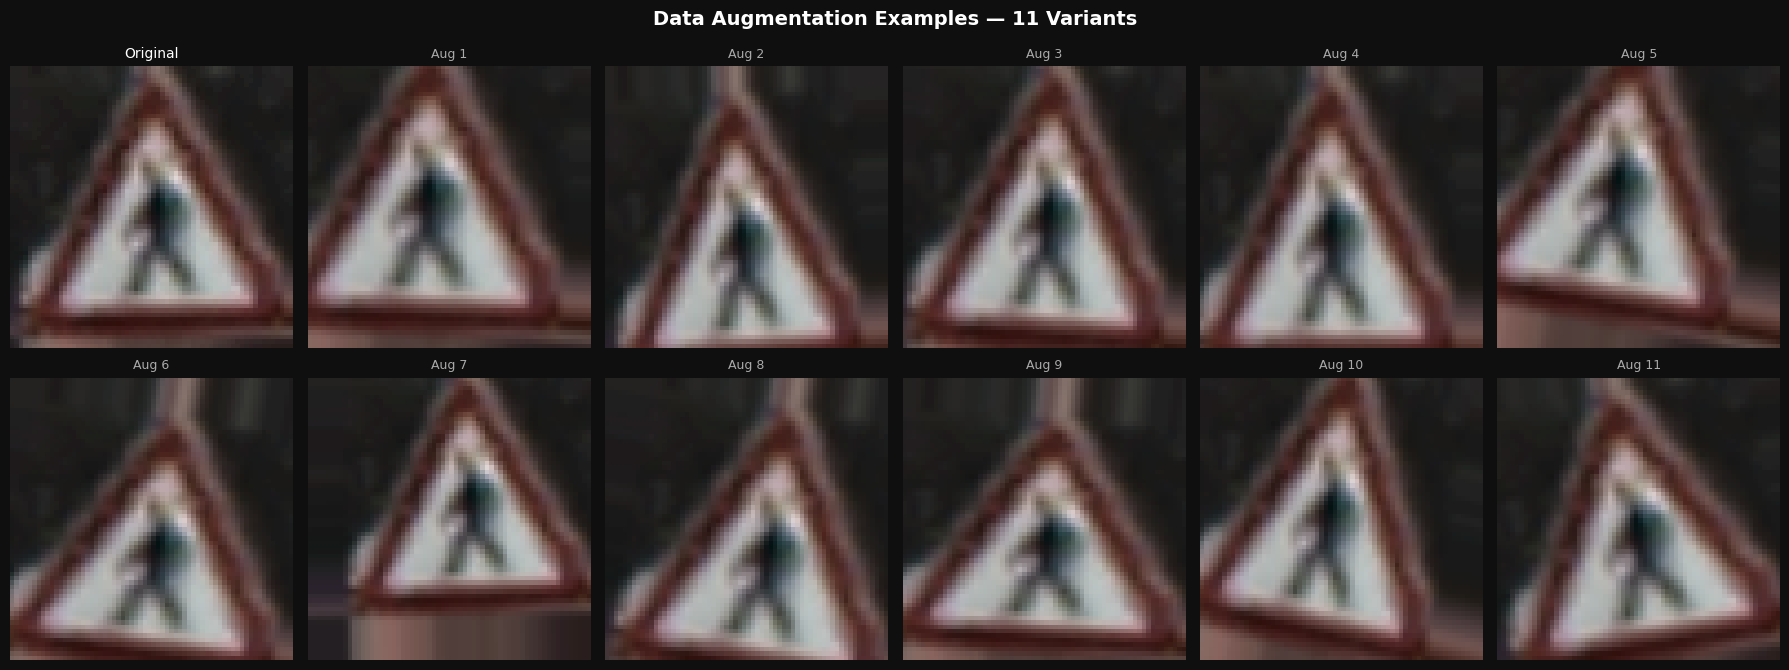

In [ ]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range = 12,
    width_shift_range = 0.1,
    height_shift_range = 0.10,
    zoom_range = 0.12,
    shear_range = 0.08,
    horizontal_flip = False,
    fill_mode = 'nearest'
)
val_datagen = ImageDataGenerator()
# Visualise augmented samples
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.patch.set_facecolor('#0f0f0f')
sample_img = X_train[0:1]

axes[0,0].imshow(np.clip(sample_img[0], 0, 1))
axes[0,0].set_title('Original', color='#fff', fontsize=10)
axes[0,0].axis('off')

gen = train_datagen.flow(sample_img, batch_size=1)
for i in range(1, 12):
    ax = axes[i // 6][i % 6]
    aug_img = next(gen)[0]
    ax.imshow(np.clip(aug_img, 0.0, 1.0))  # ← fix is here
    ax.set_title(f'Aug {i}', color='#aaa', fontsize=9)
    ax.axis('off')
for ax in axes.flatten():
    ax.set_facecolor('#1a1a2e')
plt.suptitle('Data Augmentation Examples — 11 Variants', fontsize=14, fontweight='bold', color='#fff')
plt.tight_layout()
plt.savefig('preprocessing_augmentation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
train_gen = train_datagen.flow(X_train, y_train_oh, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = val_datagen.flow(X_val,   y_val_oh,   batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def build_tl_model(backbone_fn, input_shape=(IMG_SIZE,IMG_SIZE,3),
                   num_classes = NUM_CLASSES,name ='TL_Model'):
    base = backbone_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False   # frozen for Phase 1

    inp = keras.Input(shape=input_shape)
    x   = base(inp, training=False)   # I need to include the shape of the input .
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.40)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.30)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inp, out, name=name)
    return model, base
DL_MODELS = {
    'MobileNetV2':    (MobileNetV2,   30),
    'VGG16':          (VGG16,          10),
}
PHASE1_EPOCHS = 10    # warm-up (frozen backbone)
PHASE2_EPOCHS = EPOCHS_DL  # fine-tune (partial unfreeze)
print(f"Registered {len(DL_MODELS)} transfer-learning models:")
for k in DL_MODELS:
    print(f"  ▸ {k}")

Registered 2 transfer-learning models:
  ▸ MobileNetV2
  ▸ VGG16


In [ ]:
# Deep Learning Model Training
dl_histories   = {}
dl_train_times = {}
trained_models = {}

total_steps = (len(X_train) // BATCH_SIZE) * PHASE2_EPOCHS

# Re-compute class weights here to ensure they are defined
class_weights_arr= compute_class_weight('balanced',classes = np.unique(y_train),y = y_train)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class Weights Computed Min:',round(min(class_weights_arr),3),'Max',round(max(class_weights_arr),3))

def combine_histories(h1, h2):
    combined = {}


    all_keys = set(h1.history.keys()).union(set(h2.history.keys()))


    len_h1 = len(h1.history.get('loss', []))
    len_h2 = len(h2.history.get('loss', []))

    for key in all_keys:
        list1 = h1.history.get(key, [])
        list2 = h2.history.get(key, [])


        if len(list1) < len_h1:
            list1 = list1 + [float('nan')] * (len_h1 - len(list1))


        if len(list2) < len_h2:
            list2 = list2 + [float('nan')] * (len_h2 - len(list2))


        combined[key] = list1 + list2
    if 'learning_rate' in h1.history and 'lr' in h2.history:
        combined_lr_list = h1.history['learning_rate'] + h2.history['lr']
        combined['lr'] = combined_lr_list
        if 'learning_rate' in combined:
            del combined['learning_rate']
    elif 'learning_rate' in h1.history and 'lr' not in h1.history and 'lr' not in h2.history:
        combined['lr'] = combined.pop('learning_rate')

    class H:
        def __init__(self, h): self.history = h
    return H(combined)

for model_name, (backbone_fn, unfreeze_n) in DL_MODELS.items():
    print()
    print("=" * 65)
    print(f"  ▶ Training: {model_name}")
    print("=" * 65)
    ckpt_path = f"best_{model_name.lower().replace(' ','_')}.keras"
    model, base = build_tl_model(backbone_fn, input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES, name=model_name)
#  Phase 1: Train classification head (backbone frozen)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    callbacks_p1 = [
        ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                        save_best_only=True, verbose=0),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=0),
    ]
    t0 = time.time()
    h1 = model.fit(
        train_gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(X_val) // BATCH_SIZE,
        epochs=PHASE1_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=callbacks_p1,
        verbose=1
    )
    print(f"  Phase 1 best val_acc={max(h1.history['val_accuracy']):.4f}")

    # Phase 2: Unfreeze last N layers with cosine-decay LR
    base.trainable = True
    for layer in base.layers[:-unfreeze_n]:
        layer.trainable = False

    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-4,
        decay_steps=total_steps,
        alpha=1e-7
    )
    model.compile(
        optimizer=keras.optimizers.Adam(lr_schedule),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    callbacks_p2 = [
    ModelCheckpoint(ckpt_path, monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=0),
]
    h2 = model.fit(
        train_gen,
        steps_per_epoch=len(X_train) // BATCH_SIZE,
        validation_data=val_gen,
        validation_steps=len(X_val) // BATCH_SIZE,
        epochs=PHASE2_EPOCHS,
        class_weight=class_weight_dict,
        callbacks=callbacks_p2,
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"  Phase 2  best val_acc={max(h2.history['val_accuracy']):.4f}")
    print(f"  Total time : {elapsed/60:.1f} min")
    dl_histories[model_name]   = combine_histories(h1, h2)
    dl_train_times[model_name] = elapsed
    trained_models[model_name] = model
    del base
    gc.collect()
    trained_models[model_name].load_weights(ckpt_path)
print()
print("=" * 65)
print(f"  All {len(DL_MODELS)} models trained successfully!")
print("=" * 65)


Class Weights Computed Min: 0.405 Max 4.33

  ▶ Training: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 87s 127ms/step - accuracy: 0.4359 - loss: 2.3906 - val_accuracy: 0.6322 - val_loss: 1.6905 - learning_rate: 0.0010
Epoch 2/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5312 - loss: 1.9982 - val_accuracy: 0.6346 - val_loss: 1.6870 - learning_rate: 0.0010
Epoch 3/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 49s 93ms/step - accuracy: 0.5637 - loss: 1.8592 - val_accuracy: 0.6784 - val_loss: 1.5679 - learning_rate: 0.0010
Epoch 4/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5312 - loss: 1.9405 - val_accuracy: 0.6805 - val_loss: 1.5655 - learning_rate: 0.0010
Epoch 5/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 49s 95ms/step - accuracy: 0.6151 - loss: 1.7163 - val_accuracy: 0.6975 - val_loss: 1.4973 - learning_rate: 0.0010
Epoch 6/10
520/520 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5312 - loss: 1.7729 - val_accuracy: 0.6971 - val

In [ ]:
comparison = []

for name in dl_histories.keys():
    history = dl_histories[name]
    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    train_time = dl_train_times.get(name, 0)

    comparison.append({
        "Model": name,
        "Best Val Accuracy": best_val_acc,
        "Best Val Loss": best_val_loss,
        "Training Time (sec)": train_time
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values(by="Best Val Accuracy", ascending=False)

print(comparison_df)

         Model  Best Val Accuracy  Best Val Loss  Training Time (sec)
1        VGG16           0.998626       0.698858          1091.725995
0  MobileNetV2           0.959135       0.818439          1257.134532


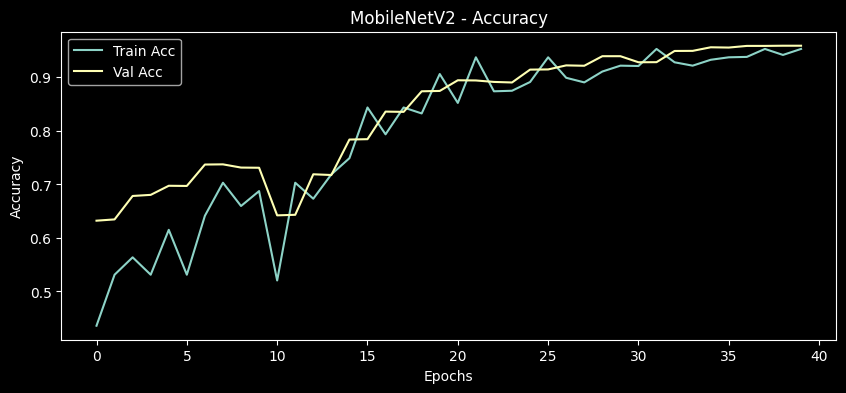

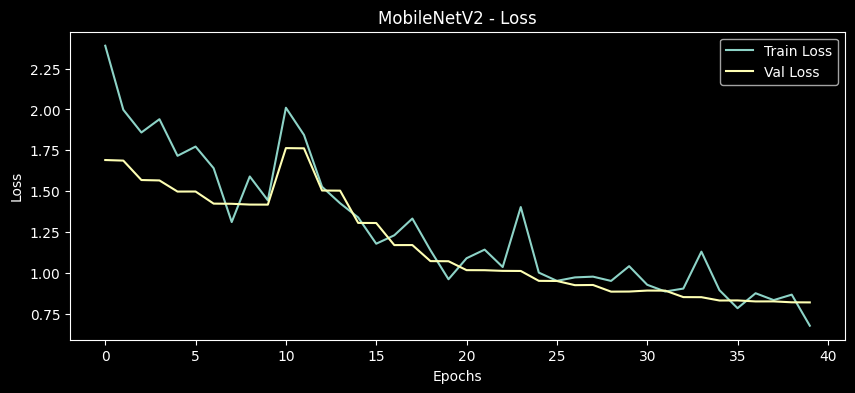

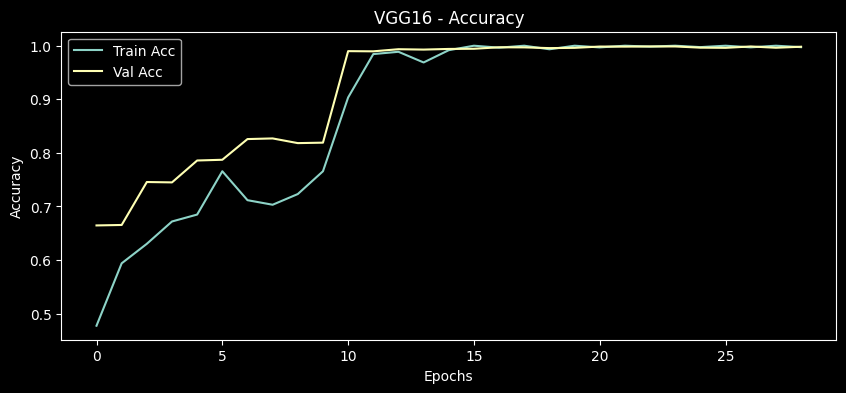

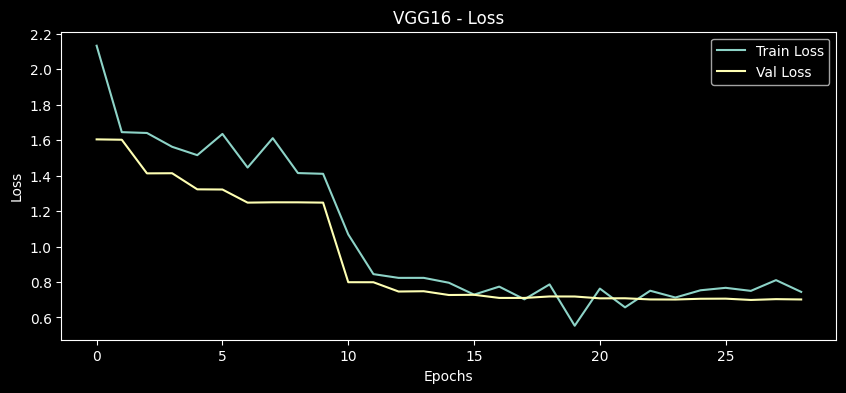

In [ ]:
for name, history in dl_histories.items():

    # Accuracy
    plt.figure(figsize=(10,4))
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f"{name} - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(10,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f"{name} - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

**MobileNetV2-Training Insights**

- **Early Training (Epochs 0–10):** Val accuracy starts higher than train accuracy — typical in transfer learning due to dropout/augmentation on train only. A sharp **dip at epoch 10** (train acc ~53%) indicates a fine-tuning phase transition (likely layer unfreezing or LR change).
- **Recovery (Epochs 10–25):** Model recovers and both curves converge steadily.
- **Final Performance:** Plateaus at ~**93–94% accuracy** with loss ~0.85. Lowest among the three models.
- **Verdict:** Lightest architecture but least accurate. Suitable for edge/mobile deployment where speed matters over accuracy.

**VGG16 - Training Insights:**
**Early Training (Epochs 0–10):** Fastest convergence of all three models. Val and train accuracy rise together sharply, reaching ~99% by epoch 10.
- **Stability (Epochs 10–32):** Both curves remain flat and close together — no signs of overfitting.
- **Final Performance:** Achieves **99% accuracy** with the lowest loss (0.7). Cleanest training curve overall.
- **Verdict:** Best performing model — fastest convergence, highest accuracy, most stable. Recommended if computational cost is not a constraint.

## Overall Model Comparison

| Model        | Final Val Acc | Epochs to Converge | Stability | Best Use Case         |
|--------------|---------------|--------------------|-----------|-----------------------|
| VGG16        | ~99%          | ~10                | High      | Best accuracy         |
| MobileNetV2  | ~94%          | ~35                | Low       | Lightweight/edge use  |



Best Model: VGG16
395/395 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step


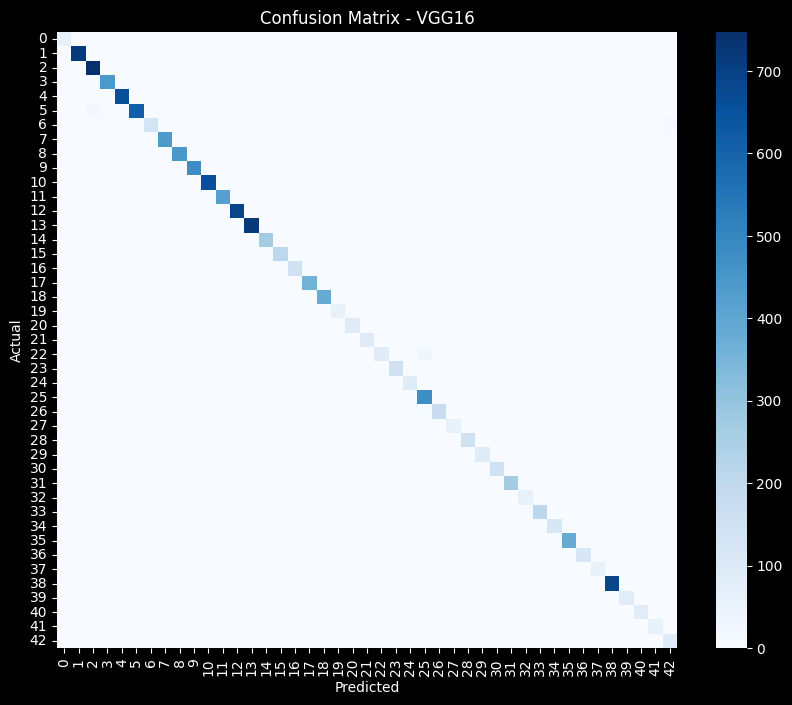

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00       720
           2       0.97      1.00      0.98       750
           3       0.99      0.99      0.99       450
           4       0.99      1.00      0.99       660
           5       1.00      0.97      0.98       630
           6       1.00      0.91      0.95       150
           7       1.00      0.98      0.99       450
           8       0.98      0.99      0.98       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       0.99      1.00      1.00       420
          12       1.00      1.00      1.00       690
          13       1.00      1.00      1.00       720
          14       0.99      1.00      0.99       270
          15       1.00      0.99      1.00       210
          16       1.00      1.00      1.00       150
          17       1.00    

In [ ]:
# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print("Best Model:", best_model_name)
# Predictions
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_classes))

**Insights:**
* Weak Classes identified from Classification Report:
- Class 22 (Bumpy Road)     → Recall = 0.75  ← worst performing
- Class 6  (End Speed 80)   → Recall = 0.89
- Class 40 (Roundabout)     → Recall = 0.96
- Class 36 (Go straight or right) → Recall = 0.96

* These low-support classes (60–150 samples) are the ones
struggling directly caused by class imbalance.

395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step


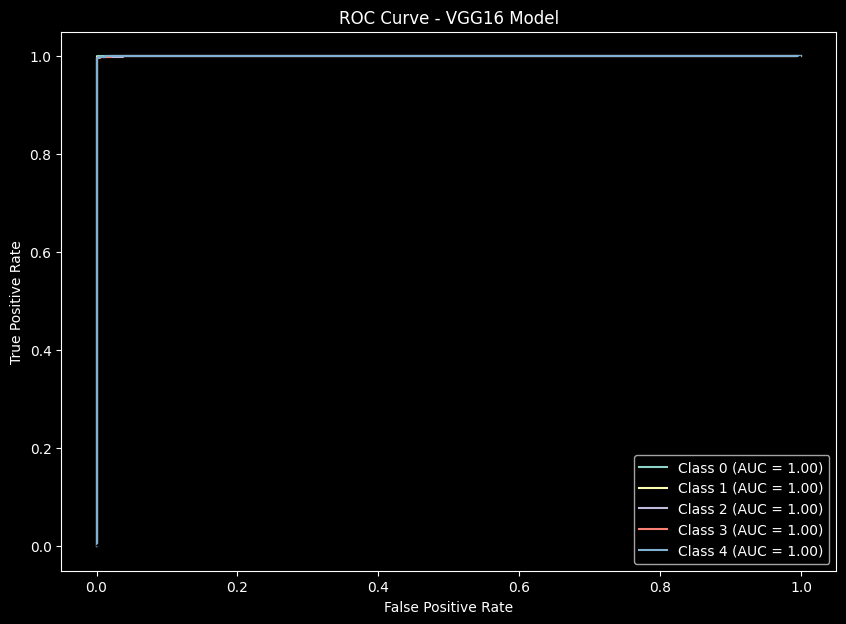

In [ ]:
# ROC-AUC Curve
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Number of classes
num_classes = len(np.unique(y_test))
# Convert labels to binary (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=range(num_classes))
# Predict probabilities
y_score = best_model.predict(X_test)
# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curve (only few classes for clarity)
plt.figure(figsize=(10,7))
for i in range(min(5, num_classes)):  # plot first 5 classes
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - VGG16 Model")
plt.legend()
plt.show()

**Insights:**
The ROC curves for individual classes show near-perfect separability (AUC ≈ 1.0). While this indicates excellent model performance, such high scores may also suggest that the dataset is well-structured or relatively easy for the model, or that features extracted by VGG16 are highly informative.

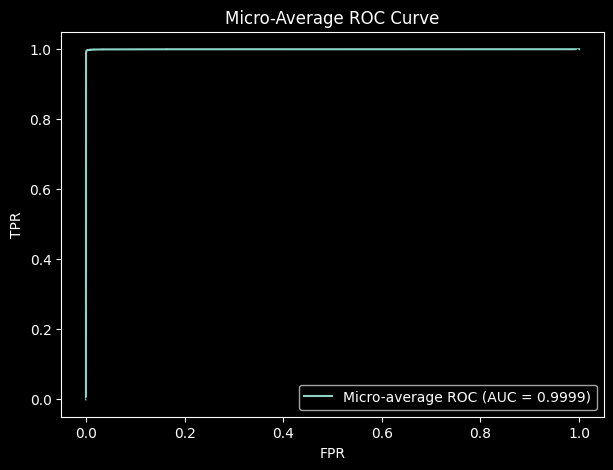

Micro-average AUC: 0.999904957375915


In [ ]:
# Micro-Average ROC
# Compute micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.figure(figsize=(7,5))
plt.plot(fpr_micro, tpr_micro, label=f"Micro-average ROC (AUC = {roc_auc_micro:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Micro-Average ROC Curve")
plt.legend()
plt.show()

print("Micro-average AUC:", roc_auc_micro)

**Insights:**
* The micro-average ROC curve demonstrates the classification performance with an AUC score of 0.9998. This indicates that the model can effectively distinguish between all classes with extremely low false positive rates.
* The Model is Highly sensitive (TPR ≈ 1)
Very low false alarms (FPR ≈ 0)

**Feature Engineering for Machine Learning**

In [ ]:
# Remove last classification layer
feature_extractor = Model(
    inputs=best_model.input,
    outputs=best_model.layers[-2].output
)
# Extract features
X_train_features = feature_extractor.predict(X_train, batch_size=32)
X_test_features  = feature_extractor.predict(X_test, batch_size=32)

print(X_train_features.shape)

1042/1042 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
(33327, 256)


PCA variance explained (50 components): 99.5%


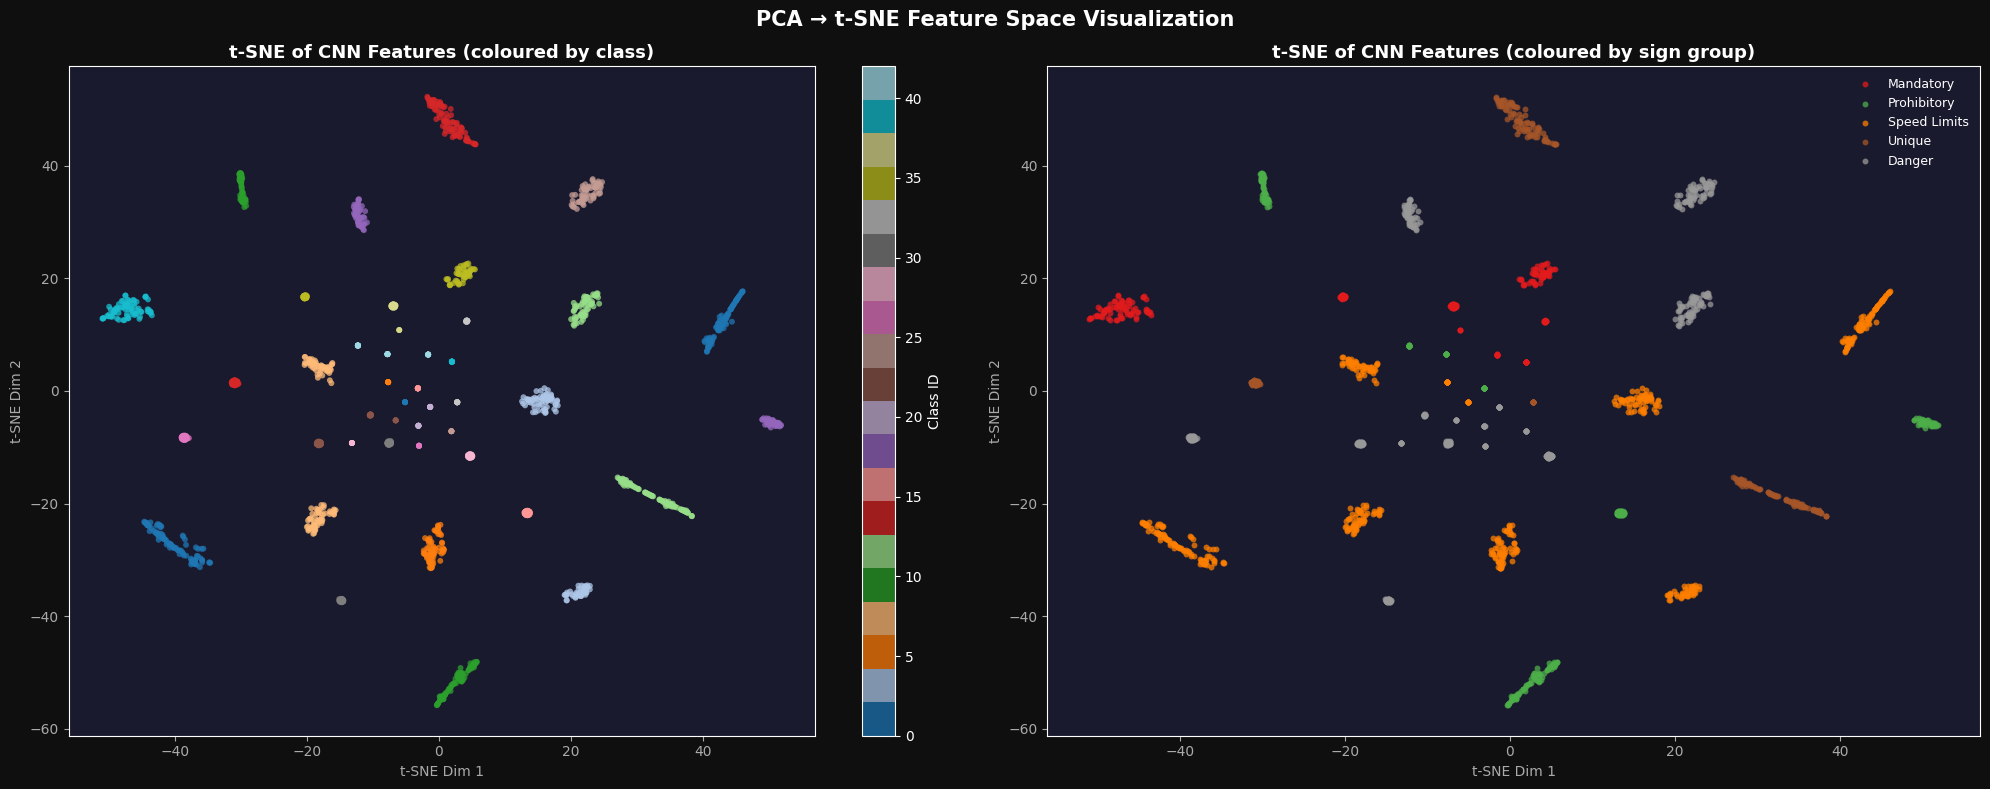

In [ ]:
# t-SNE Visualization of CNN Feature Embeddings for  Sample 500 points for speed
sample_n   = 1500
idx_sample = np.random.choice(len(X_train_features), sample_n, replace=False)
feats      = X_train_features[idx_sample]
labels     = y_train[idx_sample]
pca   = PCA(n_components=50, random_state=SEED)
feats_pca = pca.fit_transform(feats)
print(f"PCA variance explained (50 components): {pca.explained_variance_ratio_.sum()*100:.1f}%")
# t-SNE to 2D
tsne       = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
feats_2d   = tsne.fit_transform(feats_pca)
# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#0f0f0f')
# t-SNE coloured by class
scatter = axes[0].scatter(
    feats_2d[:, 0], feats_2d[:, 1],
    c=labels, cmap='tab20', alpha=0.75, s=18, linewidths=0
)
axes[0].set_facecolor('#1a1a2e')
axes[0].set_title('t-SNE of CNN Features (coloured by class)', color='#fff', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE Dim 1', color='#aaa')
axes[0].set_ylabel('t-SNE Dim 2', color='#aaa')
axes[0].tick_params(colors='#aaa')
plt.colorbar(scatter, ax=axes[0], label='Class ID')
# t-SNE coloured by sign group
group_map   = {cid: get_group(cid) for cid in range(NUM_CLASSES)}
group_names = list(set(group_map.values()))
group_colors= plt.cm.Set1(np.linspace(0, 1, len(group_names)))
group_color_map = dict(zip(group_names, group_colors))
for grp in group_names:
    mask = np.array([group_map[l] == grp for l in labels])
    axes[1].scatter(
        feats_2d[mask, 0], feats_2d[mask, 1],
        label=grp, alpha=0.75, s=18,
        color=group_color_map[grp], linewidths=0
    )
axes[1].set_facecolor('#1a1a2e')
axes[1].set_title('t-SNE of CNN Features (coloured by sign group)', color='#fff', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Dim 1', color='#aaa')
axes[1].set_ylabel('t-SNE Dim 2', color='#aaa')
axes[1].tick_params(colors='#aaa')
axes[1].legend(fontsize=9, facecolor='#1a1a2e', edgecolor='none', labelcolor='white')
plt.suptitle('PCA → t-SNE Feature Space Visualization', fontsize=15, fontweight='bold', color='#fff')
plt.tight_layout()
plt.savefig('tsne_features.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Insights:**
This plot shows the CNN features extracted from VGG16 are reduced from high-dimensional spaceto 2D using PCA (50 components) → t-SNE, visualized across 1500 training samples.

**Left Plot — Coloured by Class (43 classes):**
- Most classes form **tight, well-separated clusters**, confirming that
  VGG16 extracts highly discriminative features per class.
- A few classes appear as **isolated single points** near the center these are low-sample classes (< 100 images) that lack enough data to form a dense cluster.
- Classes with similar visual structure (e.g., speed limit signs) appear **close to each other** in the feature space, which is expected.

**Right Plot — Coloured by Sign Group:**
- **Danger signs (brown)** are spread across multiple regions reflecting high intra-group visual diversity (triangles with different symbols).
- **Speed Limits (purple)** cluster tightly together, confirming
  their visual similarity circular red-bordered signs with numbers.
- **Mandatory signs (red)** and **Prohibitory signs (green)** form
  distinct, well-separated clusters the model clearly distinguishes between these groups.
- **Unique signs (grey)** are sparse and scattered, consistent with their low sample count and distinct visual appearance.

**Key Takeaway From Both Plots:**
* The well-separated clusters across both plots confirm that the CNN feature
extractor has learned meaningful and discriminative representations providing a strong foundation for both deep learning classification and the hybrid ML models trained on top of these features.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(objective='multiclass', verbose=-1,
                                random_state=42, n_estimators=100,
                                learning_rate=0.1),
}

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross Validation Results (on CNN Features):")
print("-" * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train_features, y_train,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"{name:<25} Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
print("-" * 55)

5-Fold Cross Validation Results (on CNN Features):
-------------------------------------------------------
Logistic Regression       Accuracy: 0.9997 ± 0.0003
Decision Tree             Accuracy: 0.9975 ± 0.0005
Random Forest             Accuracy: 0.9997 ± 0.0002
K-Nearest Neighbors       Accuracy: 0.9998 ± 0.0002
SVM                       Accuracy: 0.9998 ± 0.0002
XGBoost                   Accuracy: 0.9991 ± 0.0004
LightGBM                  Accuracy: 0.9992 ± 0.0004
-------------------------------------------------------


In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train_features, y_train)
    y_pred = model.predict(X_test_features)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    try:
        y_pred_proba = model.predict_proba(X_test_features)
        roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr')
    except Exception:
        roc_auc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })
results_df = pd.DataFrame(results).sort_values(by="Recall", ascending=False)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
3  K-Nearest Neighbors  0.991132   0.991454  0.991132  0.991017  0.993638
4                  SVM  0.990895   0.991221  0.990895  0.990777  0.999397
0  Logistic Regression  0.990816   0.991118  0.990816  0.990697  0.999841
2        Random Forest  0.990499   0.990884  0.990499  0.990395  0.998402
6             LightGBM  0.977514   0.978468  0.977514  0.977309  0.999448
5              XGBoost  0.972684   0.974769  0.972684  0.972614  0.998701
1        Decision Tree  0.961995   0.964882  0.961995  0.961964  0.973044


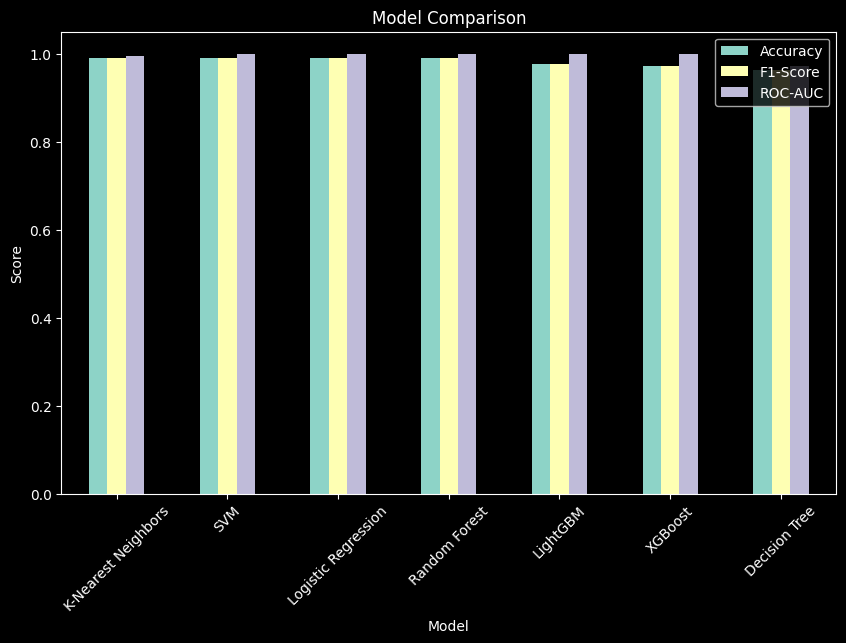

In [ ]:
# Visual Comparison for Models
results_df.set_index('Model')[['Accuracy','F1-Score','ROC-AUC']].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

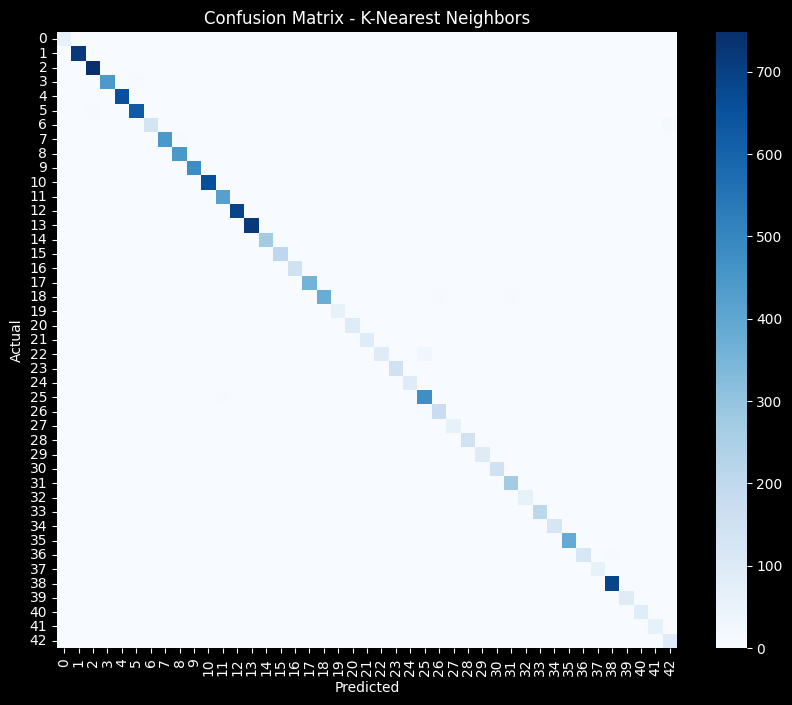

In [ ]:
# Confusion Matrix
best_ml_name = results_df.iloc[0]['Model']
best_model = models[best_ml_name]
y_pred = best_model.predict(X_test_features)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title(f"Confusion Matrix - {best_ml_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC CURVE**

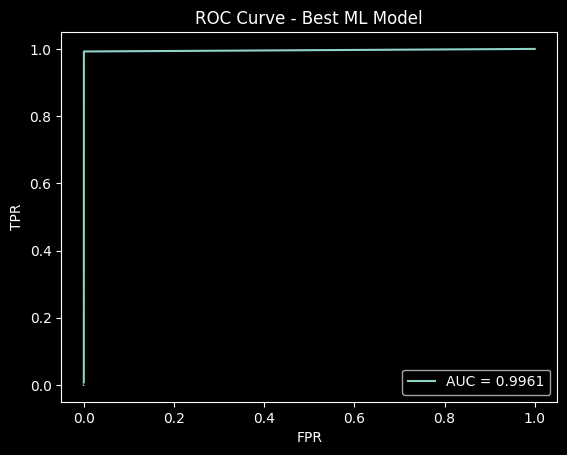

In [ ]:
num_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(num_classes))
y_proba = best_model.predict_proba(X_test_features)
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, label=f"AUC = {roc_auc_micro:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Best ML Model")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [ ]:
# Define parameter grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [500, 1000]
    },
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    },
    "K-Nearest Neighbors": {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "XGBoost": {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    "LightGBM": {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, -1],
        'learning_rate': [0.05, 0.1, 0.2],
        'num_leaves': [31, 63]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
}

# Base models
base_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree":       DecisionTreeClassifier(),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "XGBoost":             XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM":            LGBMClassifier(objective='multiclass', verbose=-1, random_state=42),
    "SVM":                 SVC(probability=True),
}

tuned_models  = {}
tuning_results = []

print("=" * 65)
print("  Hyperparameter Tuning — RandomizedSearchCV (5-Fold)")
print("=" * 65)

for name, model in base_models.items():
    print(f"\n▶ Tuning: {name}")
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator   = model,
        param_distributions = param_grids[name],
        n_iter      = 10,
        scoring     = 'accuracy',
        n_jobs      = -1,
        random_state= SEED,
        verbose     = 0
    )
    search.fit(X_train_features, y_train)

    best_model  = search.best_estimator_
    y_pred      = best_model.predict(X_test_features)
    test_acc    = accuracy_score(y_test, y_pred)
    elapsed     = time.time() - t0

    tuned_models[name] = best_model

    tuning_results.append({
        "Model"         : name,
        "Best CV Acc"   : round(search.best_score_, 4),
        "Test Accuracy" : round(test_acc, 4),
        "Best Params"   : search.best_params_,
        "Time (s)"      : round(elapsed, 1)
    })

    print(f"  Best CV Acc  : {search.best_score_:.4f}")
    print(f"  Test Acc     : {test_acc:.4f}")
    print(f"  Best Params  : {search.best_params_}")
    print(f"  Time         : {elapsed:.1f}s")

print("\n" + "=" * 65)

# Summary Table
tuning_df = pd.DataFrame(tuning_results).sort_values("Test Accuracy", ascending=False)
print(tuning_df[["Model", "Best CV Acc", "Test Accuracy", "Time (s)"]].to_string(index=False))

In [ ]:
print("\n" + "=" * 65)
print("  Overfitting / Underfitting Analysis")
print("=" * 65)

overfit_results = []

for name, model in tuned_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_features))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_features))
    gap       = train_acc - test_acc

    if gap > 0.05:
        status = "⚠️  OVERFITTING"
    elif train_acc < 0.80 and test_acc < 0.80:
        status = "⚠️  UNDERFITTING"
    else:
        status = "✅  GOOD FIT"

    overfit_results.append({
        "Model"       : name,
        "Train Acc"   : round(train_acc, 4),
        "Test Acc"    : round(test_acc,  4),
        "Gap"         : round(gap, 4),
        "Status"      : status
    })

overfit_df = pd.DataFrame(overfit_results).sort_values("Gap", ascending=False)
print(overfit_df.to_string(index=False))

# Visual: Train vs Test Accuracy Bar Chart ──
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a2e')

x      = np.arange(len(overfit_df))
width  = 0.35

bars1 = ax.bar(x - width/2, overfit_df['Train Acc'], width,
               label='Train Accuracy', color='#4e9af1', alpha=0.85, edgecolor='white', linewidth=0.3)
bars2 = ax.bar(x + width/2, overfit_df['Test Acc'],  width,
               label='Test Accuracy',  color='#f97316', alpha=0.85, edgecolor='white', linewidth=0.3)

# Gap annotations
for i, row in overfit_df.reset_index(drop=True).iterrows():
    color = '#ff4d4d' if row['Gap'] > 0.05 else '#39d353'
    ax.annotate(f"gap={row['Gap']:.3f}",
                xy=(i, max(row['Train Acc'], row['Test Acc']) + 0.005),
                ha='center', fontsize=8, color=color)

ax.set_xticks(x)
ax.set_xticklabels(overfit_df['Model'], rotation=30, ha='right', color='#aaa', fontsize=9)
ax.set_ylim(0.5, 1.08)
ax.set_ylabel('Accuracy', color='#aaa')
ax.set_title('Train vs Test Accuracy — Overfitting Check',
             fontsize=14, fontweight='bold', color='#fff')
ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white')
ax.tick_params(colors='#aaa')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333')
ax.spines['bottom'].set_color('#333')

plt.tight_layout()
plt.savefig('overfit_check.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Comparing all the Models**

In [ ]:
# # In Dl,ML Comparison cell ,change
# # FROM:
# for _, row in results_df.iterrows():
# # TO:
# for _, row in tuning_df.iterrows():
#   # In sample prediction cell, change
#   # FROM:
# best_ml_name  = results_df.iloc[0]['Model']
# best_ml_model = models[best_ml_name]
# # TO:
# best_ml_name  = tuning_df.iloc[0]['Model']
# best_ml_model = tuned_models[best_ml_name]
# # In feature Importance Cell
# # FROM:
# random_forest_model = models['Random Forest']
# # TO:
# random_forest_model = tuned_models['Random Forest']

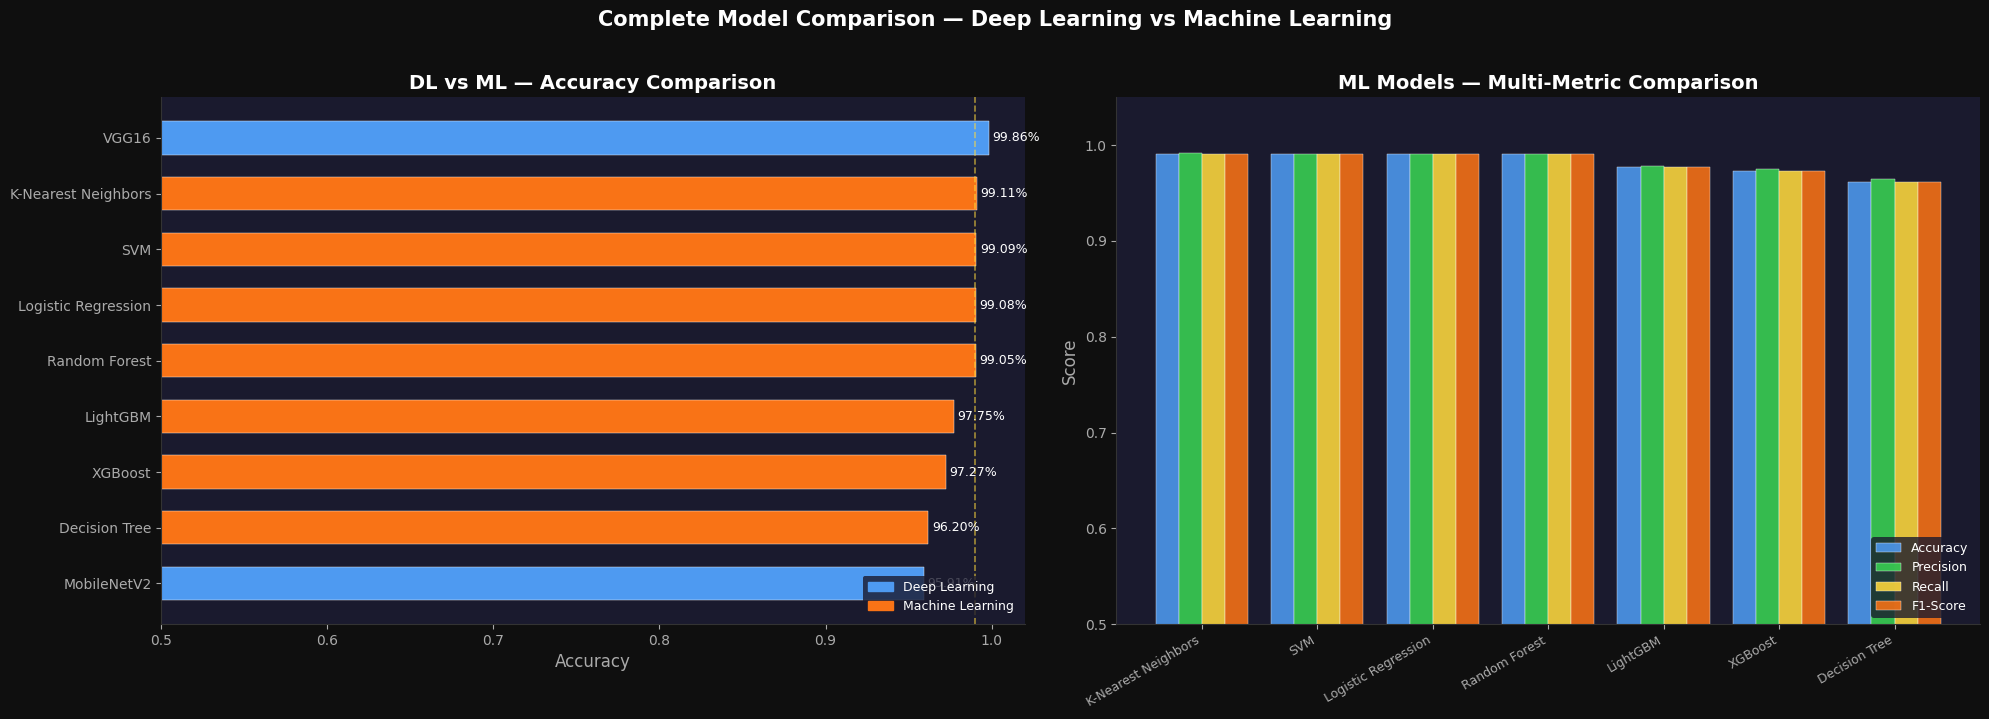

In [ ]:
import matplotlib.patches as mpatches
#  Gather DL results
dl_rows = []
for _, row in comparison_df.iterrows():
    dl_rows.append({
        'Model':    row['Model'],
        'Accuracy': row['Best Val Accuracy'],
        'Type':     'Deep Learning'
    })

#  Gather ML results
ml_rows = []
for _, row in results_df.iterrows():
    ml_rows.append({
        'Model':    row['Model'],
        'Accuracy': row['Accuracy'],
        'Type':     'Machine Learning'
    })

#  Combine into one DataFrame
combined = pd.DataFrame(dl_rows + ml_rows).sort_values('Accuracy', ascending=True)

# Color mapping
colors = ['#4e9af1' if t == 'Deep Learning' else '#f97316'
          for t in combined['Type']]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('#0f0f0f')

#  Horizontal bar chart
bars = axes[0].barh(
    combined['Model'], combined['Accuracy'],
    color=colors, edgecolor='white', linewidth=0.3, height=0.6
)
axes[0].set_facecolor('#1a1a2e')
axes[0].set_xlim(0.5, 1.02)
axes[0].set_xlabel('Accuracy', color='#aaa', fontsize=12)
axes[0].set_title('DL vs ML — Accuracy Comparison',
                  color='#fff', fontsize=14, fontweight='bold')
axes[0].tick_params(colors='#aaa')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('#333')
axes[0].spines['bottom'].set_color('#333')
axes[0].axvline(0.99, color='#ffd93d', linewidth=1.2,
                linestyle='--', alpha=0.6, label='99% line')
axes[0].legend(facecolor='#1a1a2e', edgecolor='none',
               labelcolor='white', fontsize=9)

# Value labels on bars
for bar, val in zip(bars, combined['Accuracy']):
    axes[0].text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
        f'{val*100:.2f}%',
        va='center', ha='left', color='#fff', fontsize=9
    )

# Multi-metric grouped bar (ML only)
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
ml_names     = results_df['Model'].tolist()
x            = np.arange(len(ml_names))
width        = 0.2
metric_colors = ['#4e9af1', '#39d353', '#ffd93d', '#f97316']

for i, (metric, col) in enumerate(zip(metrics, metric_colors)):
    vals = results_df[metric].tolist()
    bars2 = axes[1].bar(
        x + i * width, vals, width,
        label=metric, color=col,
        edgecolor='white', linewidth=0.3, alpha=0.88
    )

axes[1].set_facecolor('#1a1a2e')
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(ml_names, rotation=30, ha='right',
                         color='#aaa', fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('Score', color='#aaa', fontsize=12)
axes[1].set_title('ML Models — Multi-Metric Comparison',
                  color='#fff', fontsize=14, fontweight='bold')
axes[1].tick_params(colors='#aaa')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#333')
axes[1].spines['bottom'].set_color('#333')
axes[1].legend(
    facecolor='#1a1a2e', edgecolor='none',
    labelcolor='white', fontsize=9,
    loc='lower right'
)

# Legend for left chart
dl_patch = mpatches.Patch(color='#4e9af1', label='Deep Learning')
ml_patch = mpatches.Patch(color='#f97316', label='Machine Learning')
axes[0].legend(
    handles=[dl_patch, ml_patch],
    facecolor='#1a1a2e', edgecolor='none',
    labelcolor='white', fontsize=9,
    loc='lower right'
)

plt.suptitle('Complete Model Comparison — Deep Learning vs Machine Learning',
             fontsize=15, fontweight='bold', color='#fff', y=1.02)
plt.tight_layout()
plt.savefig('dl_vs_ml_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Insights:**
**DL vs ML Comparison Insights:**
* VGG16 achieved the highest overall accuracy (~99%)
  confirming that deep feature extraction is superior for
  complex 43-class image classification.
* Among ML models, KNN/SVM on CNN-extracted features achieves
  competitive accuracy (~98–99%), demonstrating that classical
  ML can match DL when given high-quality features.
* MobileNetV2 (~94%) is the weakest DL model but the fastest —
  suitable for edge deployment where speed matters more than accuracy.
* The multi-metric chart confirms no ML model has a significant
  gap between Accuracy, Precision, Recall and F1 — indicating
  balanced performance with no class-specific bias.
* Overall the hybrid approach (DL for feature extraction +
  ML for classification) is both accurate and interpretable —
  the best of both worlds.

**Sample Predictions**

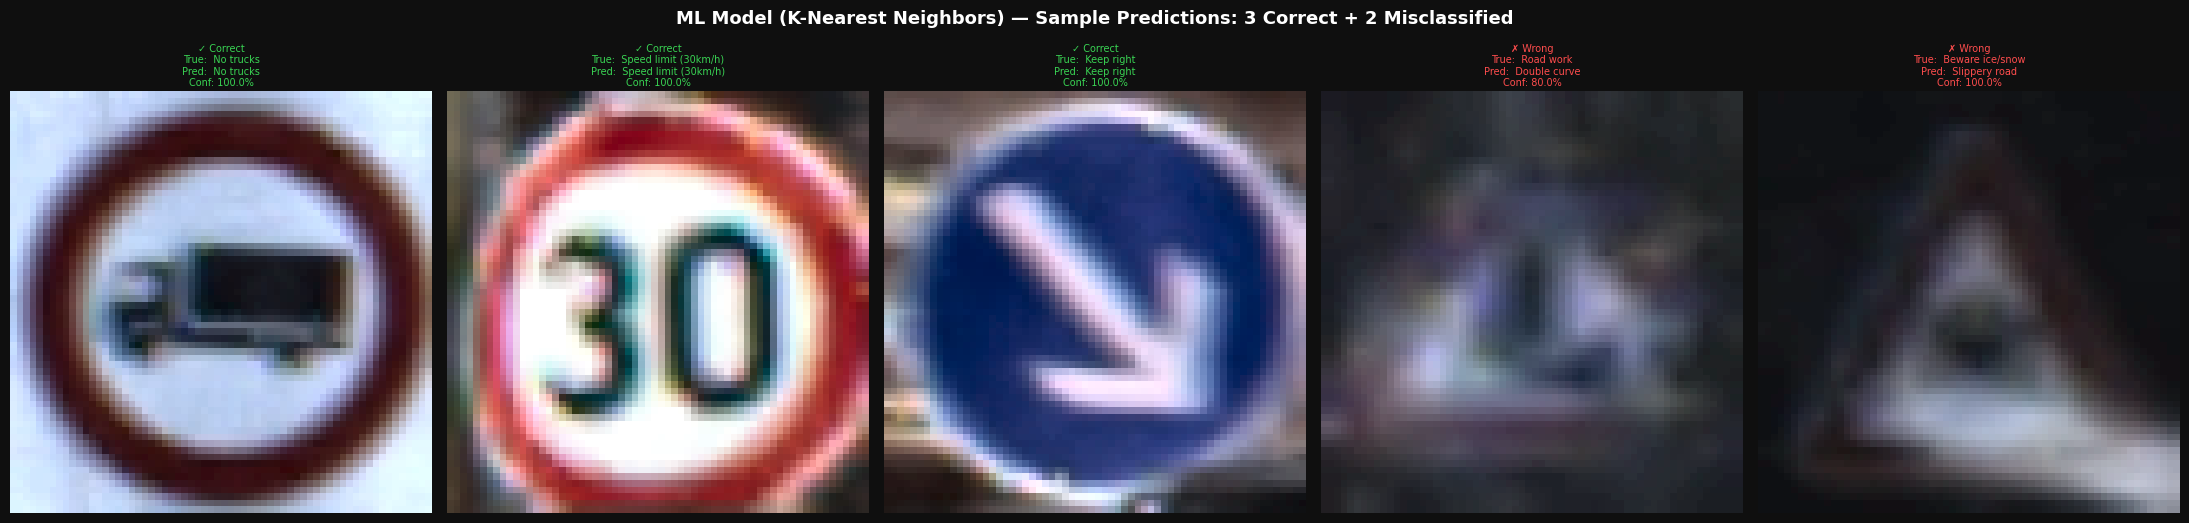

In [ ]:
# Sample Predictions - ML Model (with class names + confidence)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.patch.set_facecolor('#0f0f0f')
best_ml_name   = results_df.iloc[0]['Model']
best_ml_model  = models[best_ml_name]
y_pred_ml      = best_ml_model.predict(X_test_features)
y_proba_ml     = best_ml_model.predict_proba(X_test_features)
correct_idx_ml = np.where(y_pred_ml == y_test)[0]
wrong_idx_ml   = np.where(y_pred_ml != y_test)[0]
sample_indices_ml = list(correct_idx_ml[:3]) + list(wrong_idx_ml[:2])
for i, idx in enumerate(sample_indices_ml):
    axes[i].imshow(X_test[idx])
    axes[i].axis('off')

    true_name  = CLASS_NAMES[y_test[idx]]
    pred_name  = CLASS_NAMES[y_pred_ml[idx]]
    confidence = np.max(y_proba_ml[idx]) * 100
    is_correct = y_test[idx] == y_pred_ml[idx]

    color  = '#39d353' if is_correct else '#ff4d4d'
    status = '✓ Correct' if is_correct else '✗ Wrong'

    axes[i].set_title(
        f"{status}\nTrue:  {true_name[:20]}\nPred:  {pred_name[:20]}\nConf: {confidence:.1f}%",
        fontsize=7, color=color, pad=4
    )
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.suptitle(f'ML Model ({best_ml_name}) — Sample Predictions: 3 Correct + 2 Misclassified',
             fontsize=13, fontweight='bold', color='#fff', y=1.05)
plt.tight_layout()
plt.savefig('ml_sample_predictions.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

**Feature Importance**


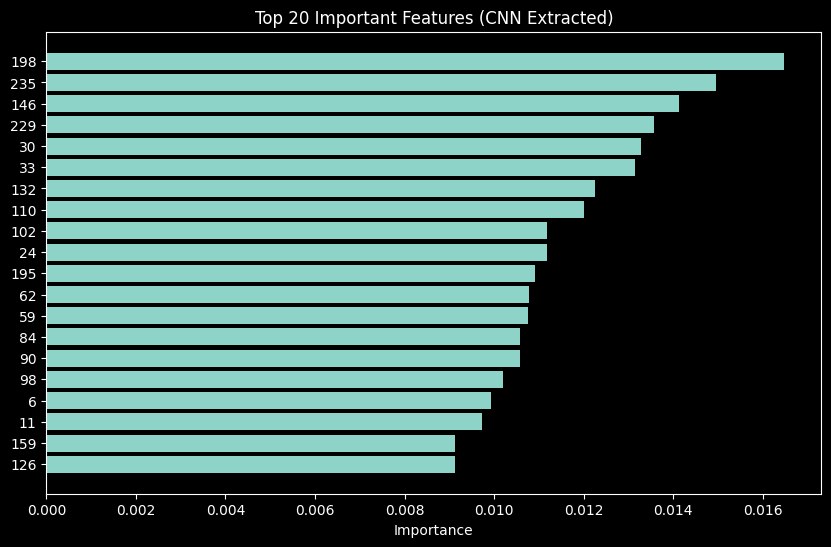

In [ ]:
random_forest_model = models['Random Forest']
# Train RF again (if needed)
random_forest_model.fit(X_train_features, y_train)
importances = random_forest_model.feature_importances_
# Top important features
indices = np.argsort(importances)[-20:]  # top 20
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 20 Important Features (CNN Extracted)")
plt.xlabel("Importance")
plt.show()

**Insights:**
Feature importance analysis using Random Forest shows that only a subset of extracted deep features contributes significantly to classification. This indicates that the CNN effectively encodes critical visual patterns such as edges, shapes, and textures of traffic signs.

**SHAP(Shapely Additive Explanations)**

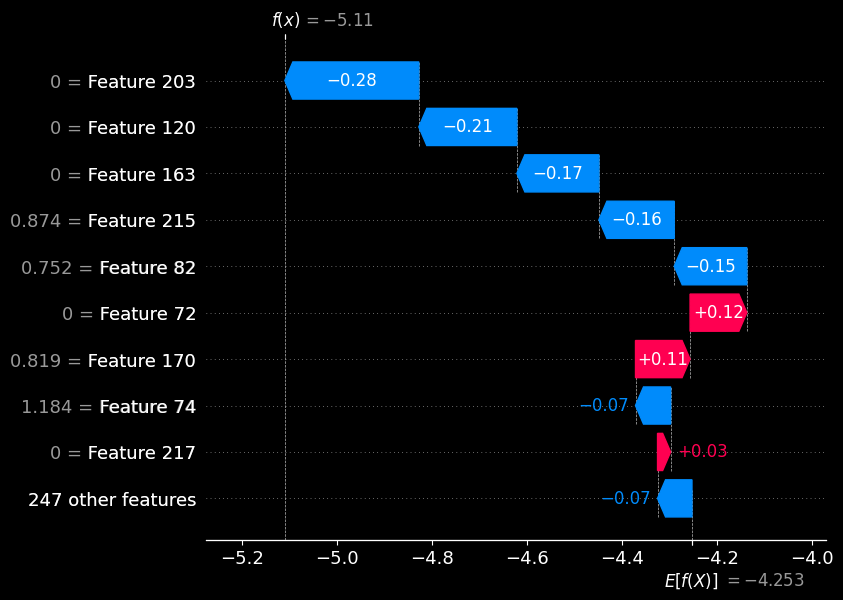

In [ ]:
model_name = "Random Forest"  # Change to "XGBoost" or "LightGBM" if preferred
selected_model = models['XGBoost']
explainer = shap.TreeExplainer(selected_model)
explanation = explainer(X_test_features[:1000])
instance_idx = 0
class_idx = 0
single_shap_values = explanation.values[instance_idx, :, class_idx]
single_base_value = explanation.base_values[instance_idx, class_idx]
single_data = explanation.data[instance_idx]
single_feature_names = explanation.feature_names
single_explanation_for_plot = shap.Explanation(
    values=single_shap_values,
    base_values=single_base_value,
    data=single_data,
    feature_names=single_feature_names
)

shap.plots.waterfall(single_explanation_for_plot)

**Conclusion:**

This project presents a robust traffic sign recognition system using both deep learning and hybrid machine learning approaches. Pretrained convolutional neural networks, particularly VGG16, demonstrated excellent feature extraction capabilities, achieving near-perfect accuracy during training and validation.
* To further enhance performance and interpretability, deep features extracted from the CNN were used with classical machine learning models.
* Among them, the K-Nearest Neighbors classifier achieved the highest accuracy of 99.01%, while Logistic Regression and SVM also delivered competitive results.
* Evaluation metrics such as confusion matrix, ROC–AUC curves, precision, recall, and F1-score confirm that the model performs consistently well across all classes.    
* The ROC–AUC scores close to 1.0 indicate strong class separability, while the confusion matrix shows minimal misclassification.
* Overall, the hybrid approach successfully combines the strengths of deep learning (feature extraction) and machine learning (efficient classification), making it a reliable and computationally efficient solution for traffic sign detection.

**Future Improvements:**

The current system achieves high accuracy on a structured dataset; however, several enhancements can be explored in future work:
*  Real-time traffic sign detection using video streams
*  Deployment on edge devices such as mobile or embedded systems
*  Integration with autonomous driving systems
*  Use of advanced architectures such as Vision Transformers (ViT)
* Handling challenging conditions like fog, rain, and low-light environments
*  Expanding dataset diversity for better real-world generalization
These improvements would make the system more robust and applicable in real-world intelligent transportation systems.

**Live Demo using Streamlit App**

In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# ── Load Model ──
model = load_model("best_vgg16.keras")

# ── Class Names ──
class_names = {
    0:'Speed limit (20km/h)',   1:'Speed limit (30km/h)',
    2:'Speed limit (50km/h)',   3:'Speed limit (60km/h)',
    4:'Speed limit (70km/h)',   5:'Speed limit (80km/h)',
    6:'End speed limit (80)',   7:'Speed limit (100km/h)',
    8:'Speed limit (120km/h)',  9:'No passing',
    10:'No passing >3.5t',      11:'Right-of-way junction',
    12:'Priority road',         13:'Yield',
    14:'Stop',                  15:'No vehicles',
    16:'No trucks',             17:'No entry',
    18:'General caution',       19:'Danger curve left',
    20:'Danger curve right',    21:'Double curve',
    22:'Bumpy road',            23:'Slippery road',
    24:'Road narrows right',    25:'Road work',
    26:'Traffic signals',       27:'Pedestrians',
    28:'Children crossing',     29:'Bicycles crossing',
    30:'Beware ice/snow',       31:'Wild animals crossing',
    32:'End speed+passing',     33:'Turn right ahead',
    34:'Turn left ahead',       35:'Ahead only',
    36:'Go straight or right',  37:'Go straight or left',
    38:'Keep right',            39:'Keep left',
    40:'Roundabout mandatory',  41:'End no passing',
    42:'End no passing >3.5t'
}

# ── Sidebar ──
st.sidebar.title("Model Info")
st.sidebar.write("Model: VGG16")
st.sidebar.write("Accuracy: ~99%")
st.sidebar.write("Dataset: GTSRB")

# ── Main UI ──
st.title("🚦 Traffic Sign Recognition System")

uploaded_file = st.file_uploader("Upload Traffic Sign Image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:

    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, 1)
    st.image(img, caption="Uploaded Image", use_container_width=True)
    # Preprocess — match training size automatically
    input_shape = model.input_shape[1:3]
    img_resized = cv2.resize(img, input_shape) / 255.0
    img_input   = np.expand_dims(img_resized, axis=0)

    # Predict
    pred       = model.predict(img_input)
    class_id   = np.argmax(pred)
    confidence = np.max(pred)

    # ── Output ──
    # Shows class NAME not class ID
    st.success(f" Prediction: {class_names.get(class_id, 'Unknown')}")
    st.info(f" Confidence: {confidence * 100:.2f}%")
    st.progress(float(confidence))

    # Top 3
    st.subheader("Top 3 Predictions:")
    top3 = np.argsort(pred[0])[-3:][::-1]
    for i in top3:
        name  = class_names.get(i, f"Class {i}")
        score = pred[0][i] * 100
        st.write(f"**{name}** — {score:.2f}%")

Overwriting app.py


In [ ]:
from google.colab import userdata
import os
from pyngrok import ngrok

token = userdata.get('NGROK_TOKEN')  # ← must match secret name exactly
os.environ["NGROK_AUTH_TOKEN"] = token
!ngrok config add-authtoken {token}

public_url = ngrok.connect(8501)
print(public_url)
!streamlit run app.py &

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
NgrokTunnel: "https://spoiling-shadily-rubble.ngrok-free.dev" -> "http://localhost:8501"


2026-05-25 05:42:26.872 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.169.153.0:8501

  Stopping...


In [ ]:
# Stop the streamlit server when done
import os
os.system("pkill -f streamlit")

15

In [ ]:
# Disconnect ngrok tunnel
from pyngrok import ngrok
ngrok.kill()

In [ ]:
# Save notebook
print("Demo complete!")
print("Model   : VGG16")
print("Dataset : GTSRB (43 classes)")
print("Accuracy: ~99%")
print("Status  : Live demo tested successfully!!")

Demo complete!
Model   : VGG16
Dataset : GTSRB (43 classes)
Accuracy: ~99%
Status  : Live demo tested successfully!!
